# Исследование рынка точек общественного питания Москвы

- Автор: Федоров Алексей Анатольевич
- Дата: 12.04.2026

### Цели и задачи проекта

Найти главные факторы, влияющие на увеличение рейтинга точки питания в Москве: расположение, размер, режим работы, тип точки, ценовой сегмент. Чтобы дать рекомендации, как открывать новые точки общественного питания с более высокой проходимостью, так как рейтинг увеличивает проходимость, а значит и выручку.

### Описание данных

#### Датасет **rest_info.csv** - информация о точках общественного питания
* **name** — название заведения;
* **address** — адрес заведения;
* **district** — административный район (например, Центральный административный округ);
* **category** — категория заведения (например, «кафе», «пиццерия» или «кофейня»);
* **hours** — информация о днях и часах работы;
* **rating** — рейтинг заведения по оценкам пользователей в Яндекс Картах (макс. 5.0);
* **chain** — является ли заведение сетевым (0 — нет, 1 — да);
* **seats** — количество посадочных мест.

#### Датасет **rest_price.csv** - информация о среднем чеке в точках питания
* **price** — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

* **avg_bill** — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    * «Средний счёт: 1000–1500 ₽»;
    * «Цена чашки капучино: 130–220 ₽»;
    * «Цена бокала пива: 400–600 ₽» и так далее;

* **middle_avg_bill** — число с оценкой среднего чека, которое указано только для значений из столбца **avg_bill**, начинающихся с подстроки «Средний счёт»:
    * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    * Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.

* **middle_coffee_cup** — число с оценкой одной чашки капучино, которое указано только для значений из столбца **avg_bill**, начинающихся с подстроки «Цена одной чашки капучино»:
    * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    * Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

#### Поля, важные для анализа
- category;
- district/category;
- chain/category;
- seats/category;
- rating/category;
- rating - корреляция с другими атрибутами;
- top 15 по name/avg rating/category;
- avg bill/district.




### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговый вывод и рекомендации.
---

## Конфигурирование среды

### Установка и импорты

In [1]:
!pip install phik
!pip install --upgrade matplotlib==3.4.3

In [2]:
import os
import sys
import numpy as np
import pandas as pd
from IPython.display import Markdown, HTML

# Графика, диаграммы и гистограммы, тепловые карты
import matplotlib
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# Расчёт коэффициента корреляции phi_k
import phik
from phik import phik_matrix

print(
    f"Путь к Python: {sys.executable}",
    f"Версия Python: {sys.version}",
    f"Текущий путь: {os.getcwd()}",
    f"pandas: {pd.__version__}",
    f"Бэкенд pandas (plotting): {pd.options.plotting.backend}",
    f"phik: {phik.__version__}",
    f"matplotlib: {matplotlib.__version__}",
    f"seaborn: {sns.__version__}",
sep='\n')

Путь к Python: /opt/conda/bin/python
Версия Python: 3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0]
Текущий путь: /home/jovyan/work
pandas: 1.2.4
Бэкенд pandas (plotting): matplotlib
phik: 0.12.5
matplotlib: 3.4.3
seaborn: 0.11.1


### Общие функции

In [3]:
def show_ds_short_info(df):
    """
        Выводит информацию о размерности датасета и перечень колонок.
    """
    print(
        f'\tВсего: {df.shape[0]} строк, {df.shape[1]} колонок',
        f'\tКолонки датасета: {df.columns.tolist()}\n', sep='\n')
    
def show_item(num, name, action):
    """
        Отображает любой шаг анализа, заданный через func, в виде блока с заголовком.
    """
    print(f'{num}. {name}', '=' * 20)
    action()    
    
def show(start_num, *name_action):
    """
        Отображает шаги анализа с заголовком, нумерацией и разделением.
        Стартовая нумерация задайтся в start_num.
        Шаги переаются списком аргументов переменной длины: name, action. 
    """
    if len(name_action) % 2:
        raise ValueError('Нечётное число аргументов. В show передавайте пары значений name, action как единый список аргументов.')
    
    num_args = len(name_action)
    num = start_num
    
    for i in range(0, num_args, 2):
        if i != 0:
            print('\n')
        show_item(num, name_action[i], name_action[i + 1])
        num += 1
        if i < i - 2:
            print('\n')
            
def get_missing_values_statistics(df, name=None):
    """
        Проверяет все колонки DataFrame df на пропуски: np.nan, None, pd.NA.
        Возвращает DataFrame, содержащий две колоки: число пропусков и % пропусков по мнению функции isna( ).        
        В качестве индекса выступают имена колонок. Возвращаются только строки с ненулевыми данными.
    """
    subject = df if name is None else df[name]
    missing_count_seria = subject.isna().sum().loc[lambda v: v > 0].sort_values(ascending=False)
    missing_fraction = round(missing_count_seria / df.shape[0] * 100, 2)
    result = pd.DataFrame({'Пропущено (np.nan, None, pd.NA)': missing_count_seria, 'Доля пропусков %': missing_fraction})
    
    return 'В колонках DataFrame нет пропусков' if result.empty else result

def normalize_text_cols(df, *col_names, to_lower=True):
    """
        Конвертирует колонки col_names в string, обрезает пробелы с концов и нормализует пробелы внутри строк.
        Если задано to_lower, то приводит к нижнему регистру.
    """
    for name in col_names:        
        df[name] = df[name].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
        if to_lower:
            df[name] = df[name].str.lower()
 
def get_whiskers(values, coeff=1.5, left=None, right=None):
    """
        Возвращает усы ящика для серии values.
    """
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    w_left = Q1 - coeff * IQR
    w_right = Q3 + coeff * IQR
    
    if left is not None:
        w_left = max(left, w_left)
    if right is not None:
        w_right = min(right, w_right)
        
    return w_left, w_right

def get_reference_info(df, name, numeric=False):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 150 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    lst = values.tolist()
    
    display(Markdown(f"**{name}:** `{lst[:150]}` = **{len(lst)}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def report_row_removing(before, after):
    print(f'✅ Из датасета в {before} строк удалено 🗑️ {before - after} строк,\n'
        f'\tосталось: {after} строк,\n'
        f'\tпроцент потерь: {round((before - after) / before * 100, 2)}%.')

    

## 1. Загрузка данных и знакомство с ними


### Конфигурация

In [4]:
BASE_DS_PATH = "https://code.s3.yandex.net/datasets/"
DATASET_INFO_PATH = BASE_DS_PATH + 'rest_info.csv'
DATASET_PRICE_PATH = BASE_DS_PATH + 'rest_price.csv'

### Загрузка и оценка данных

In [5]:
rest_info_df = pd.read_csv(DATASET_INFO_PATH, skipinitialspace=True)
rest_price_df = pd.read_csv(DATASET_PRICE_PATH, skipinitialspace=True)

# сохраним размерность исходных данных для сравнения после обработки
rest_info_df_shape = rest_info_df.shape
rest_price_df_shape = rest_price_df.shape

In [6]:
show(1, 
     'Датасет "Точки питания"', lambda: show_ds_short_info(rest_info_df),
     'info', lambda: rest_info_df.info(),
     'Пропуски данных по колонкам', lambda: display(get_missing_values_statistics(rest_info_df)),
     'Пример данных', lambda: display(rest_info_df),
)

1. Датасет "Точки питания" ====================
	Всего: 8406 строк, 9 колонок
	Колонки датасета: ['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats']



2. info ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


3. Пропуски данных по колонкам ====================


,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
seats,3611,42.96
hours,536,6.38




4. Пример данных ====================


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0


✅ Мы видим, что предоставлено 8406 записей, колонки соотвествуют описанию и в Snake Case, вместимость и часы работы с пропусками 43% и 6% соотвественно.

In [7]:
show(1, 
     'Датасет "Цены"', lambda: show_ds_short_info(rest_price_df),
     'info', lambda: rest_price_df.info(),
     'Пропуски данных по колонкам', lambda: display(get_missing_values_statistics(rest_price_df)),
     'Пример данных', lambda: display(rest_price_df),
)

1. Датасет "Цены" ====================
	Всего: 4058 строк, 5 колонок
	Колонки датасета: ['id', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']



2. info ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


3. Пропуски данных по колонкам ====================


,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
middle_coffee_cup,3523,86.82
middle_avg_bill,909,22.40
price,743,18.31
avg_bill,242,5.96




4. Пример данных ====================


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
...,...,...,...,...,...
4053,962800540173458486f3c465437c2d8b,средние,Цена бокала пива:от 140 ₽,NaN,NaN
4054,4277890d659341848d7051cbf2e51f51,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
4055,026cbc478f9b4c3294a83458dcd89982,средние,NaN,NaN,NaN
4056,71cc394927204d45b81c3a91edb47955,NaN,Средний счёт:50–250 ₽,150.0,NaN


Здесь видим, что в датасете 4058 записей, что почти **в 2 раза меньше** первого датасета (8406). 
Кроме того, в 6% пропущен avg_bill и в 18% ценовая категория точки.
Тоесть, данные по ценам есть менее, чем для половины точек. 
Это вызвано тем, что они заполняются посетителями и берутся из интернета в случайном режиме.

❗Для анализа нужен avg_bill, поэтому: подумать как заполнить. Видимо свести цены в одну колонку по категории точки.

### Проверка ключевых столбцов и настройка индексов

In [8]:
print(rest_info_df['id'].is_unique)
print(rest_price_df['id'].is_unique)

True
True


✅ Индексы по id уникальны. Пропусков нет. Установим их и приведём к string.

In [9]:
rest_info_df['id'] = rest_info_df['id'].astype('string')
rest_price_df['id'] = rest_price_df['id'].astype('string')

rest_info_df.set_index('id', inplace=True)
rest_price_df.set_index('id', inplace=True)

### Типизируем и нормализуем текстовые колонки, чтобы видеть неявные дубликаты

✅ Текстовые строки по-умолчанию идут с типом object и могут иметь лишние пробелы внутри, а так же, набраны на разном регистре. Чтобы упростить их сравнение нормализуем их:
- удаляем лишние пробелы;
- приводим к lower case;
- и к типу string, пропуски заменяем на pd.NA.

In [10]:
normalize_text_cols(rest_info_df, 'name', 'category', 'address', 'district', 'hours')
normalize_text_cols(rest_price_df, 'price', 'avg_bill')

### Проверим значения в колонках

#### Непрерывные и числовые значения

In [11]:
show(1,
     'Датасет "Точки питания", числовые', lambda: display(rest_info_df.describe()),
     'Датасет "Цены", числовые', lambda: display(rest_price_df.describe()),
    )

1. Датасет "Точки питания", числовые ====================


,rating,chain,seats
count,8406.000000,8406.000000,4795.000000
mean,4.229895,0.381275,108.421689
std,0.470348,0.485729,122.833396
min,1.000000,0.000000,0.000000
25%,4.100000,0.000000,40.000000
50%,4.300000,0.000000,75.000000
75%,4.400000,1.000000,140.000000
max,5.000000,1.000000,1288.000000




2. Датасет "Цены", числовые ====================


,middle_avg_bill,middle_coffee_cup
count,3149.000000,535.000000
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.000000,60.000000
25%,375.000000,124.500000
50%,750.000000,169.000000
75%,1250.000000,225.000000
max,35000.000000,1568.000000


❗Видим, что у seats std > mean и медиана 75, а среднее 108. min = 0. Значит, **пропуски 43%** могут быть неслучайными. Например, категория "Еда на вынос". Нужно обработать, проверить выбросы.
Добавить колонку 👉**has_seats**: 0, 1. seats нужен для анализа.

🆗chain - данные хорошие. Пропусков нет.

❗rating - данные смещены в зону 4-4.5. Пропусков нет. Надо проверить на выбросы на графике. 📊

-----------

❗middle_avg_bill - проверить на выбросы 0 - 35 000. std больше среднего. Выправить.

❗middle_coffee_cup - надо слить в одну колонку с middle_avg_bill в зависимости от avg_bill. Видимо зависит от категории точки. Проверить выбросы: 60 - 1568.

❗Для анализа нужна одна колонка. middle_avg_bill и middle_coffee_cup и avg_bill и price корелированы. На их основе можно построить производную колонку без пропусков, но надо убедиться, что есть связь с category.
👉Завести колонку **corrected_avg_bill**.


In [12]:
show(1,
     'Датасет "Точки питания", строковые', lambda: display(rest_info_df.describe(include='string')),
     'Датасет "Цены", строковые', lambda: display(rest_price_df.describe(include='string')),
    )

1. Датасет "Точки питания", строковые ====================


,name,category,address,district,hours
count,8406,8406,8406,8406,7870
unique,5512,8,5752,9,1307
top,кафе,кафе,"москва, проспект вернадского, 86в",центральный административный округ,"ежедневно, 10:00–22:00"
freq,189,2378,28,2242,759




2. Датасет "Цены", строковые ====================


,price,avg_bill
count,3315,3816
unique,4,897
top,средние,средний счёт:1000–1500 ₽
freq,2117,241


❗Видим, что 189 безымянных точек, больше всего точек типа Кафе, больше всего точек расположены в **ЦАО** и самый частый график работы **10-22**.

🆗 category без пропусков, больше всего **кафе**.

❗Есть странный адрес "москва, проспект вернадского, 86в", где зарегистрировано сразу 28 точек в одном месте. Проверить на дубликат.

🆗 district без пропусков, больше всего **ЦАО**.

❗hours есть пропуски 6%, надо анализировать чем заполнить. Рабочим будет новое поле **is_24_7**. Важно, чтобы оно было верным.

🆗 По ценовой категории price данные качественные, если не считать пропусков: самая популярная Средняя и счёт 1000-1500р.

👉 avg_bill надо разбить, выделив колонку-категорию avg_type.

#### Катеригориальные и текстовые значения

Теперь проверим катеригориальные колонки на метки пропуска данных. Например, none, tdb, - и тд. Для этого проверим уникальность и встречамость значений. Так же, не мешает проверить таким же способом и текстовые некатегориальные колонки.

In [13]:
get_reference_info(rest_info_df, 'category', False)

**category:** `['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']` = **8**



,count,%
кафе,2378,28.29
ресторан,2043,24.30
кофейня,1413,16.81
"бар,паб",765,9.10
пиццерия,633,7.53
быстрое питание,603,7.17
столовая,315,3.75
булочная,256,3.05



Пропущено: 0




🆗Category качественный. Без пропусков. Надо исследовать наличие мест и добавить поле **has_seats = 0, 1**.

In [14]:
get_reference_info(rest_info_df, 'district', False)

**district:** `['восточный административный округ', 'западный административный округ', 'северный административный округ', 'северо-восточный административный округ', 'северо-западный административный округ', 'центральный административный округ', 'юго-восточный административный округ', 'юго-западный административный округ', 'южный административный округ']` = **9**



,count,%
центральный административный округ,2242,26.67
северный административный округ,900,10.71
южный административный округ,892,10.61
северо-восточный административный округ,891,10.60
западный административный округ,851,10.12
восточный административный округ,798,9.49
юго-восточный административный округ,714,8.49
юго-западный административный округ,709,8.43
северо-западный административный округ,409,4.87



Пропущено: 0




🆗 District качественный. Без пропусков.
✅ Для анализа нужна метрика удалённости от центра: distance: 0, 1, 2, где 0 - это центр, а 2 - это диагональ.

In [15]:
def district_distance(d):
    if pd.isna(d):
        return d
    if d.find('центральный') != -1:
        return 0
    if d.find('северо-') != -1 or d.find('юго-') != -1:
        return 2
    return 1
rest_info_df['distance'] = rest_info_df['district'].map(district_distance).astype('Int8')

In [16]:
get_reference_info(rest_price_df, 'price', False)

**price:** `['высокие', 'выше среднего', 'низкие', 'средние', <NA>]` = **5**



,count,%
средние,2117,52.17
<NA>,743,18.31
выше среднего,564,13.90
высокие,478,11.78
низкие,156,3.84



Пропущено: 743




🆗Price качественный. Если не считать пропусков. Каждая вторая точка из описанных **средней ценовой категории**, а дешёвых всего 4%. ❗Колонку можно восстановить.

### Приведём числовые типы к оптимальным

- rating 1 - 5 (дробный): Float32; 🆗
- chain 0 - 1: Int8; 🆗
- seats 0 - 1288: Int16; ❗проверить на выброс

- middle_avg_bill 0 - 35 000: Int32; ❗проверить на выброс
- middle_avg_cap 60 - 1 568: Int32. ❗проверить на выброс

✅ 

In [17]:
rest_info_df = rest_info_df.astype({'rating': 'Float32', 'chain': 'Int8', 'seats': 'Int16'})
rest_price_df = rest_price_df.astype({'middle_avg_bill': 'Int32', 'middle_coffee_cup': 'Int32'})

In [18]:
show(1, 
     'Датасет "Точки питания"', lambda: rest_info_df.info(),
     'Датасет "Цены"', lambda: rest_price_df.info(),
    )

1. Датасет "Точки питания" ====================
<class 'pandas.core.frame.DataFrame'>
Index: 8406 entries, 0c3e3439a8c64ea5bf6ecd6ca6ae19f0 to 9d56f8f7a7f74df1a925bc0fd2de8aae
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      8406 non-null   string 
 1   category  8406 non-null   string 
 2   address   8406 non-null   string 
 3   district  8406 non-null   string 
 4   hours     7870 non-null   string 
 5   rating    8406 non-null   Float32
 6   chain     8406 non-null   Int8   
 7   seats     4795 non-null   Int16  
 8   distance  8406 non-null   Int8   
dtypes: Float32(1), Int16(1), Int8(2), string(5)
memory usage: 492.5+ KB


2. Датасет "Цены" ====================
<class 'pandas.core.frame.DataFrame'>
Index: 4058 entries, 045780ada3474c57a2112e505d74b633 to 62e8c64d4c89467aba608e39ef87616b
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  --

---

### Промежуточный вывод


In [19]:
print('Исходные числа строк:', rest_info_df_shape[0], ',', rest_price_df_shape[0])

Исходные числа строк: 8406 , 4058


- Имеется 8000+ записей о точках питания с уникальными id, но без проверки на дубликаты.
- Данные описанию соотвествуют и имеют верные имена колонок.
- Пропуски есть в атрибуте seats ~43% и hours ~6%. Также, почти 50% пропусков в ценовом датасете, плюс в полях самого датасета, но внутри есть сильная кореляция полей, поэтому их можно восстанавливать.
- Типы данных **неоптимальные**, но неявных пропусков нет, поэтому их удалось привести к нужным типам за один шаг.
- Атрибут **hours** нам нужен для вычисления флага **is_24_7**, это будем делать после полной проверки очистки дубликатов.
- Атрибут **seats** нужен для анализа. Тут пропуски можно восстановить по среднему из группы category, district. Так же, число по category, если это Еда на вынос или что-то в этом роде, где зала не предполагается. Для этого сбросим в 0 и добавим флаг has_seats = 0, 1.

### Подготовка единого датафрейма


✅ Мёржим таблицы по уникальному индексу id точки.

In [20]:
rest_df = rest_info_df.join(rest_price_df, how='left')
rest_df_shape = rest_df.shape
print(rest_df_shape)

(8406, 13)


## 2. Предобработка данных


Сейчас проверим явные дубликаты: одна и таже точка на одном адресе: с учётом категории и без.

In [21]:
alt_key = ['name', 'category', 'address']
explicit_dups = rest_df[rest_df.duplicated(subset=alt_key, keep=False)]
display(explicit_dups.sort_values(by='name'))

,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup
id,,,,,,,,,,,,,
62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,1,<NA>,<NA>,<NA>,<NA>
a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,1,<NA>,<NA>,<NA>,<NA>
072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,1,<NA>,<NA>,<NA>,<NA>
897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,1,<NA>,<NA>,<NA>,<NA>


In [22]:
rest_df = rest_df.drop_duplicates(subset=alt_key, keep='last')

In [23]:
alt_key = ['name', 'address']
explicit_dups = rest_df[rest_df.duplicated(subset=alt_key, keep=False)]
display(explicit_dups.sort_values(by='name'))
rest_df = rest_df.drop_duplicates(subset=alt_key, keep='first')

,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup
id,,,,,,,,,,,,,
c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,2,<NA>,<NA>,<NA>,<NA>
aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,2,<NA>,<NA>,<NA>,<NA>
3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,1,<NA>,<NA>,<NA>,<NA>
d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,<NA>,4.1,0,276,1,<NA>,<NA>,<NA>,<NA>


In [24]:
report_row_removing(rest_df_shape[0], rest_df.shape[0])

✅ Из датасета в 8406 строк удалено 🗑️ 4 строк,
	осталось: 8402 строк,
	процент потерь: 0.05%.


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [25]:
rest_df['is_24_7'] = rest_df['hours'].str.contains('круглосуточно', na=0).astype('Int8')

✅ Добавили признак круглосуточной работы точки питания **is_24_7**.

In [26]:
rest_df['avg_bill_type'] = rest_df['avg_bill'].str.split(':').str[0].astype('string')

✅ Добавили катеригориальную колонку **avg_bill_type**, чтобы проверить, как распарсена avg_bill.

In [27]:
get_reference_info(rest_df, 'avg_bill_type', False)

**avg_bill_type:** `['средний счёт', 'цена бокала пива', 'цена чашки капучино', <NA>]` = **4**



,count,%
<NA>,4586,54.58
средний счёт,3149,37.48
цена чашки капучино,535,6.37
цена бокала пива,132,1.57



Пропущено: 4586




In [28]:
display(rest_df.query('avg_bill_type == "цена бокала пива"'))

,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type
id,,,,,,,,,,,,,,,
ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",северный административный округ,"ежедневно, круглосуточно",4.5,0,102,1,средние,цена бокала пива:250–350 ₽,<NA>,<NA>,1,цена бокала пива
fca6820ccef64456b90326102d6aebb7,штаб квартира,"бар,паб","москва, дубнинская улица, 32",северный административный округ,"пн-чт 12:30–00:00; пт,сб 12:30–02:00; вс 12:30...",5.0,0,16,1,средние,цена бокала пива:120–350 ₽,<NA>,<NA>,0,цена бокала пива
670b0b0cf7f449078be63932ee9f2139,жигулевское,"бар,паб","москва, бибиревская улица, 7к2",северо-восточный административный округ,"пн-чт 14:00–00:00; пт,сб 14:00–02:00; вс 14:00...",4.5,0,<NA>,2,средние,цена бокала пива:90–230 ₽,<NA>,<NA>,0,цена бокала пива
ac6218d4cd524f359ba9dbd6ae22dada,алиби,"бар,паб","москва, улица малыгина, 1, стр. 2",северо-восточный административный округ,пн-чт 11:00–00:00; пт-вс 11:00–05:00,4.4,0,40,2,выше среднего,цена бокала пива:160–499 ₽,<NA>,<NA>,0,цена бокала пива
6ac0e6250be341b7b76cfa1d8047392a,сибирская корона,"бар,паб","москва, планерная улица, 12к1",северо-западный административный округ,"ежедневно, 12:00–00:00",4.3,0,<NA>,2,средние,цена бокала пива:199–300 ₽,<NA>,<NA>,0,цена бокала пива
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0e605a9a62c341dd897dda7279f22128,green pub,"бар,паб","москва, корабельная улица, 13",южный административный округ,"ежедневно, 11:00–23:00",4.6,0,<NA>,1,выше среднего,цена бокала пива:280–410 ₽,<NA>,<NA>,0,цена бокала пива
0bfc388e788348fa9adf5ed6cf8465e0,river’s. bar гастробар,"бар,паб","москва, нагатинская набережная, 32, корп. 1",южный административный округ,"ежедневно, 12:00–00:00",4.4,0,40,1,высокие,цена бокала пива:190–390 ₽,<NA>,<NA>,0,цена бокала пива
fa8d86fa829949bf92dce713b761d60e,триггер,"бар,паб","москва, варшавское шоссе, 45",южный административный округ,пн-пт 12:00–01:00; сб 16:00–01:00,4.4,0,42,1,средние,цена бокала пива:220–250 ₽,<NA>,<NA>,0,цена бокала пива


In [29]:
display(rest_df.query('avg_bill_type == "цена чашки капучино"').sample(15))

,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type
id,,,,,,,,,,,,,,,
756bd2c1c0fc47489038b5db255b6972,шоколадница,кофейня,"москва, зубовский бульвар, 17, стр. 1",центральный административный округ,"ежедневно, круглосуточно",4.2,1,320,0,средние,цена чашки капучино:239–274 ₽,<NA>,256,1,цена чашки капучино
4a4c992eb7eb480a9d3a8d1fc3f0eeaf,кофепорт,кофейня,"москва, каширское шоссе, 3, корп. 2, стр. 4",южный административный округ,пн-пт 08:00–18:30,4.0,1,40,1,<NA>,цена чашки капучино:90–100 ₽,<NA>,95,0,цена чашки капучино
9aef60a0bfb74bd4a143ad36f2f3ec49,coffee guru,кофейня,"москва, новодмитровская улица, 2, корп. 1",северо-восточный административный округ,"пн-пт 08:00–21:00; сб,вс 11:00–21:00",4.2,1,80,2,<NA>,цена чашки капучино:от 89 ₽,<NA>,89,0,цена чашки капучино
873b57c73f2d4bfe8fa50249c527f380,шоколадница,кофейня,"москва, проспект мира, 97",северо-восточный административный округ,"пн-ср 07:00–23:00; чт 07:00–00:00; пт,сб кругл...",4.1,1,143,2,средние,цена чашки капучино:239–274 ₽,<NA>,256,1,цена чашки капучино
6453f9dbe2e84457851a9f7a4b3a267d,everest coffee,кофейня,"москва, сходненская улица, 50",северо-западный административный округ,"пн-чт 08:00–22:00; пт 08:00–23:00; сб,вс 09:00...",4.9,0,0,2,средние,цена чашки капучино:200–300 ₽,<NA>,250,0,цена чашки капучино
fd35643213cc4cc7b7a2f524ba01ee2d,шоколадница,кофейня,"москва, люсиновская улица, 13с1",центральный административный округ,"пн-пт 08:00–22:00; сб,вс 10:00–21:00",4.2,1,<NA>,0,средние,цена чашки капучино:239–274 ₽,<NA>,256,0,цена чашки капучино
52a1e9b1cdf7454185c3473f01bead93,шоколадница,кофейня,"москва, ярцевская улица, 32",западный административный округ,"пн-пт 07:30–22:00; сб,вс 09:00–22:00",4.2,1,94,1,средние,цена чашки капучино:150–290 ₽,<NA>,220,0,цена чашки капучино
26db51964e8b47e8a2dbeaf9d548abc1,кофе стоп,кофейня,"москва, монтажная улица, 8",восточный административный округ,пн-пт 09:00–21:00,4.3,0,<NA>,1,средние,цена чашки капучино:130–160 ₽,<NA>,145,0,цена чашки капучино
6553a9e499fc4ea5a63604a0eb62b6da,мадам москвичка,кофейня,"москва, ореховый бульвар, 47/33",южный административный округ,"пн-пт 08:00–21:00; сб,вс 09:00–21:00",4.0,0,4,1,<NA>,цена чашки капучино:от 130 ₽,<NA>,130,0,цена чашки капучино


❗Тут видим, что у нас разобраны не все виды avg_bill. "цена бокала пива" не разобраны вообще. Поэтому, нужно переразобрать всю колонку заново и слить в одну общую avg_bill_actual: соберём в неё данные из колонок middle, а если они пустые, то парсим из avg_bill, иначе, оставим pd.NA.
Также, видим, что бывают два вида цен: ОТ и МЕЖДУ. Если указана одна цена, то она копируется в колонку avg, а если две, то ставится среднее значение, что не очень правильно. Одна цена - это минимум, а не среднее.
Вот поэтому, лучше пересобрать avg_bill в новую колонку по правилам. И использовать для анализа именно её. 

👉 Сделаем это позже, отдельным пунктом.

### Исправление поля seats (пропуски и выбросы)

In [30]:
get_reference_info(rest_df, 'seats', True)

**seats:** `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 104, 105, 106, 107, 108, 110, 112, 113, 114, 115, 116, 118, 120, 122, 124, 125, 126, 127, 128, 130, 131, 132, 133, 135, 138, 140, 141, 143, 144, 145, 146, 147, 148, 150, 151, 154, 155, 157, 158, 159, 160, 161, 164, 165, 166, 167, 168, 170, 173, 174, 175, 176, 178, 180, 184, 185, 187]` = **230**



,count,%
<NA>,3610,42.97
40,253,3.01
100,213,2.54
60,175,2.08
50,168,2.00
...,...,...
212,1,0.01
236,1,0.01
268,1,0.01
308,1,0.01



Пропущено: 3610
min = 0, mean = 108.36, max = 1288, median = 75.0
left_whisker = 0, right_whisker = 290.0
Нецифровые значения: [<NA>]




In [31]:
# Это похоже на выброс, и поэтому будем исключать через колонку seats_type = 2
display(rest_df.query('seats > 1000').sort_values('seats', ascending=False).head())

,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type
id,,,,,,,,,,,,,,,
fbf22d98b62a47fbb2a71be3545f16b2,delonixcafe,ресторан,"москва, проспект вернадского, 94, корп. 1",западный административный округ,"ежедневно, круглосуточно",4.1,0,1288,1,высокие,средний счёт:1500–2000 ₽,1750,<NA>,1,средний счёт
c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"москва, проспект вернадского, 121, корп. 1",западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,1288,1,выше среднего,средний счёт:1500 ₽,1500,<NA>,0,средний счёт
5925d9677fe24778a27e35ccd88c0a2d,мюнгер,пиццерия,"москва, проспект вернадского, 97, корп. 1",западный административный округ,"пн-пт 08:00–21:00; сб,вс 10:00–21:00",4.8,1,1288,1,<NA>,<NA>,<NA>,<NA>,0,<NA>
0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288,1,<NA>,<NA>,<NA>,<NA>,0,<NA>
19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","москва, проспект вернадского, 97, корп. 1",западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,0,1288,1,средние,средний счёт:700 ₽,700,<NA>,0,средний счёт


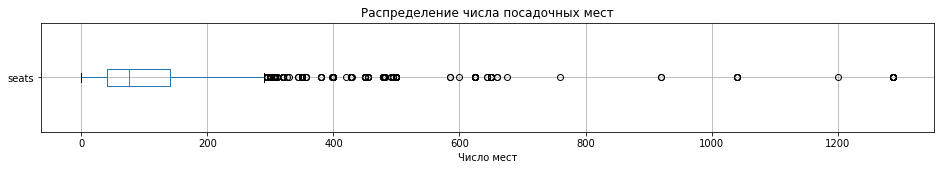

In [32]:
plt.figure(figsize=(16, 2))

# Строим диаграмму размаха значений в столбце balance
rest_df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение числа посадочных мест')
plt.xlabel('Число мест')

# Выводим график
plt.show()

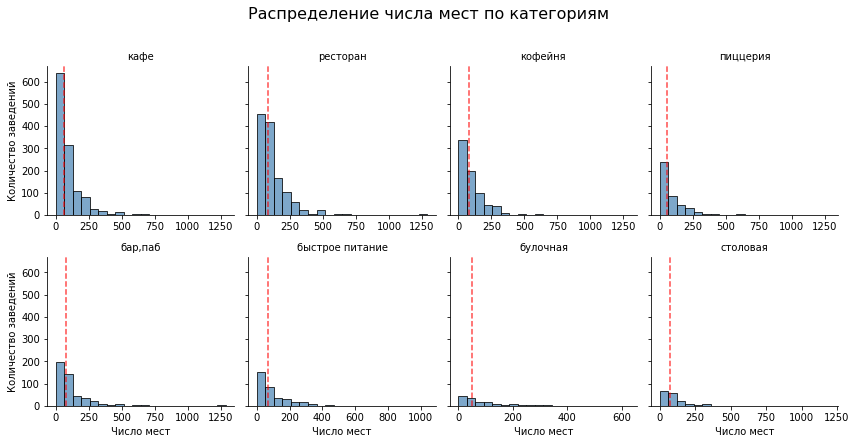

In [33]:
g = sns.FacetGrid(rest_df, col='category', col_wrap=4, height=3, sharex=False)
g.map(sns.histplot, 'seats', bins=20, color='steelblue', alpha=0.7)

# Добавляем вертикальные линии медианы
def add_median_line(data, **kwargs):
    median_val = data['seats'].median()
    plt.axvline(median_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

g.map_dataframe(add_median_line)

g.set_titles('{col_name}')
g.set_axis_labels('Число мест', 'Количество заведений')
g.fig.suptitle('Распределение числа мест по категориям', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

👉 Видим, что у seats мода 40, медиана 132, а среднее 184, при этом есть правые выбросы. Чтобы вести правильный анализ сделаем так:
- пустые значения заполним медианой по группе (category, district) отфильтровав по seats_type = 1;
- добавим колонку **seats_type** = 0, 1, 2;
- 0: если seats < 5 (Еда на вынос);
- 2: если seats > правого уса по category правый эксцесс (различные банкетные залы);
- 1: иначе (номальные значения).

✅Заполняем пропуски в seats медианой

In [34]:
# Правый ус надо вычислить сейчас, до заполнения, так как медиана изменится
_, whisker_right = get_whiskers(rest_df['seats'], left=rest_df['seats'].min(), right=rest_df['seats'].max())
print(f'Правый ус: {whisker_right}\n')

print('Медианы до:', rest_df.groupby('category')['seats'].median())

seats_means = rest_df.groupby(['category', 'district'])['seats'].transform('median')
rest_df['seats'] = rest_df['seats'].fillna(seats_means.astype(float).round()).astype('Int16')

# это для пустых групп, чтобы не появилось N/A
rest_df['seats'] = rest_df['seats'].fillna(0)

print('\nМедианы после:', rest_df.groupby('category')['seats'].median())

Правый ус: 290.0

Медианы до: category
бар,паб            82.0
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: Float64

Медианы после: category
бар,паб            90.0
булочная           50.0
быстрое питание    70.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           95.0
столовая           72.0
Name: seats, dtype: Float64


✅ Размечаем виды seats флагом **seats_type**.

In [35]:
def get_upper_whisker(group):
    # _, whisker_right = get_whiskers(group, left=group.min(), right=group.max())
    # return whisker_right
    return group.quantile(0.75)
    
category_whiskers = rest_df.groupby('category')['seats'].apply(get_upper_whisker)
print('Правый ус:', category_whiskers)

def seats_to_type(row, whiskers_dict):        
    seats = row['seats']
    cat = row['category']
    
    # Получаем ус именно для этой категории
    upper_limit = whiskers_dict.get(cat, 0)
    
    if pd.isna(seats):
        return pd.NA

    if seats < 5:
        return 0
    if seats > upper_limit:
        return 2
    return 1

rest_df['seats_type'] = rest_df.apply(
    lambda row: seats_to_type(row, category_whiskers), 
    axis=1
).astype('Int8')

Правый ус: category
бар,паб             96.0
булочная            90.5
быстрое питание    100.0
кафе                84.0
кофейня             96.0
пиццерия            90.0
ресторан           100.0
столовая           100.0
Name: seats, dtype: float64


In [36]:
display(rest_df[['name', 'seats', 'seats_type', 'category', 'district', 'rating']].sample(30))

,name,seats,seats_type,category,district,rating
id,,,,,,
4ea693e9a67f4d6db51619c312fc1f01,чайхона айва,84,1,кафе,центральный административный округ,4.3
29a41fa8878e4032bdab072f40849c0a,uilliam's,49,1,ресторан,центральный административный округ,4.5
4b1169021ed44f77a0cc02a0c095cb43,one price coffee,350,2,кофейня,северо-восточный административный округ,4.0
8921c9d6df60459ca16785502b3daec6,georgian garden,75,1,кафе,восточный административный округ,4.8
cf2d2308630e40c1b30613bb8384c1de,литл осака бар,190,2,ресторан,юго-западный административный округ,4.6
0126da526a2942f7b2350a6738f53b5e,helltower57,100,1,ресторан,западный административный округ,4.5
7376328cf240492ebcc203a4498ef9c9,турист,130,2,ресторан,северо-восточный административный округ,4.1
177f9dc2df1541c183b425a91b965fc5,чайхона,48,1,кафе,восточный административный округ,4.0
26550ec0f1ca46019a55c79cc030f810,бишкек сити,70,1,ресторан,юго-западный административный округ,3.7


### Проверяем поле rating

In [37]:
print(rest_df['rating'].describe())
print('Пропуски:', rest_df['rating'].isna().sum())

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64
Пропуски: 0


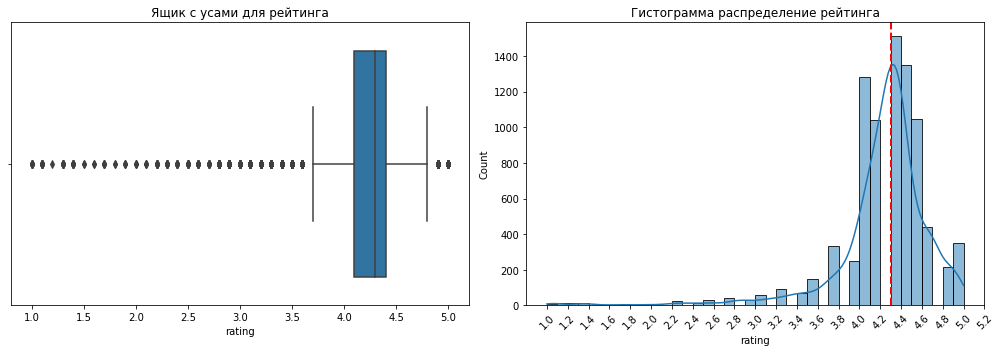

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ящик с усами, чтобы посмотреть выбросы
sns.boxplot(x=rest_df['rating'].dropna().astype(float), ax=axes[0])
axes[0].set_title('Ящик с усами для рейтинга')

# Гистограмма распределения рейтингов
sns.histplot(rest_df['rating'].dropna().astype(float), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Гистограмма распределение рейтинга')
axes[1].set_xticks(np.arange(1, 5.4, 0.2))
axes[1].tick_params(axis='x', rotation=45) 

median_val = rest_df['rating'].median()
axes[1].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()

👉 Видно, что рейтинги смещены в область 4 - 4.6, медиана 4.3, левый ус 3.6 и за ним очень много выбросов, но мы их оставим. Это могут быть трешовые точки питания.

✅ Тут добавим колонку с категорией **rating_cat**. 

In [39]:
rest_df['rating_cat'] = pd.cut(rest_df['rating'].astype('float'), bins=[0, 3, 4, 4.5, 5.1], labels=["Низкая", "Средняя", "Высокая", "Очень высокая"], right=False).astype('string')

In [40]:
display(rest_df[['name', 'seats', 'category', 'district', 'rating', 'rating_cat']].sample(10))

,name,seats,category,district,rating,rating_cat
id,,,,,,
79fc1e81701a4d6481208b9e377a5b6d,yammy,44,ресторан,северо-восточный административный округ,4.1,Высокая
8dd70226292842a0bafceef8f4e2f4f3,второе кафе,10,кофейня,центральный административный округ,4.4,Высокая
8cd94b54d05f4f86ad0cb670834f7a11,oh my david,90,"бар,паб",центральный административный округ,4.3,Высокая
5d8041b0e036464884a51d2cf3da75eb,чайхана исфисор,350,кафе,северный административный округ,4.1,Высокая
ad70df51c12442a9be0e693760ba907b,coffee and the city,96,кофейня,западный административный округ,3.9,Средняя
4d452b65f7c84583bef436f9eadbb3ef,kulinari,90,ресторан,западный административный округ,4.4,Высокая
2903d4e4b42c4232b70d218160f9616e,черетто море,275,ресторан,западный административный округ,4.7,Очень высокая
4a91a64812724c5fb73a0e9ff28bda68,арцеу,60,кафе,северо-восточный административный округ,4.5,Очень высокая
b61f6b3b25014555a25de835426c24f8,чайхана халяль,65,кафе,северный административный округ,4.2,Высокая


### Проверяем безымянные кафе

In [41]:
print(rest_df[rest_df['name'] == 'кафе'].shape[0])
display(rest_df.query('name == "кафе" and hours.isna() and price.isna() and avg_bill.isna() and middle_avg_bill.isna() and middle_coffee_cup.isna()').head())

188


,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type,seats_type,rating_cat
id,,,,,,,,,,,,,,,,,
e5f4ff8c7196472eac2c980fc6b2e9b2,кафе,кафе,"москва, ижорская улица, 18, стр. 1",северный административный округ,<NA>,3.7,0,50,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Средняя
a9ad4bd7e15c4b8cb6295c745e5a11c1,кафе,"бар,паб","москва, мкад, 82-й километр, вл18",северо-восточный административный округ,<NA>,4.2,0,62,2,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Высокая
e14d752227704822964731977a47d198,кафе,кафе,"москва, шенкурский проезд, 14",северо-восточный административный округ,<NA>,4.3,0,50,2,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Высокая
3e07170bfb584d66b8005ca5352529b6,кафе,кафе,"москва, строительный проезд, 6, корп. 1",северо-западный административный округ,<NA>,4.2,0,95,2,<NA>,<NA>,<NA>,<NA>,0,<NA>,2,Высокая
2f978e52f2d64babb2ccfd4d4cfe91ec,кафе,кафе,"москва, улица свободы, 99",северо-западный административный округ,<NA>,4.2,0,95,2,<NA>,<NA>,<NA>,<NA>,0,<NA>,2,Высокая


👉 Таким точек без названия 188. Однако, Даже в этих 3-х есть rating, часы. Можно оставить. name никак не влияет на анализ.

### Проверяем странный адрес на 28 кафе в одном доме

In [42]:
one_addr_cafes = rest_df.query('address == "москва, проспект вернадского, 86в"')
print(one_addr_cafes.shape[0])
display(one_addr_cafes.sample(7))

28


,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type,seats_type,rating_cat
id,,,,,,,,,,,,,,,,,
ed8da8dc33034f20a750e89189a833e6,bổ,кафе,"москва, проспект вернадского, 86в",западный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 11:00...",4.7,0,63,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Очень высокая
7fa12d63f8934aa986cbc01f64ecb78f,птишу,кафе,"москва, проспект вернадского, 86в",западный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 11:00...",4.0,1,63,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Высокая
0a192afa3b834d4d9384d922cccca548,fibo pasta & ravioli,кафе,"москва, проспект вернадского, 86в",западный административный округ,пн-сб 10:00–22:00; вс 11:00–22:00,4.8,1,63,1,средние,средний счёт:500–1000 ₽,750,<NA>,0,средний счёт,1,Очень высокая
557322ce6a5e49799a311e4d47f83277,юность,кафе,"москва, проспект вернадского, 86в",западный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 11:00...",4.7,1,63,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Очень высокая
b26c562796bc452db9bc3c562d8552e8,nova bubble tea,кафе,"москва, проспект вернадского, 86в",западный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 11:00...",4.2,1,63,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Высокая
02667191fb934b1288c8028e33443f79,ванильный шпатель,быстрое питание,"москва, проспект вернадского, 86в",западный административный округ,"ежедневно, 10:00–23:00",4.9,0,100,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Очень высокая
ab5b01b71964447eb1b8a97ef753668e,пark,ресторан,"москва, проспект вернадского, 86в",западный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 11:00...",3.9,0,100,1,<NA>,<NA>,<NA>,<NA>,0,<NA>,1,Средняя


👉 После анализа стало понятно, что это Парк фуд холл, и там действительно очень много кафе на одной площадке. Так оно и есть, поэтому, оставляем.

### Исправление информации о ценах с пропусками данных около 50%

Тут первое, что сделаем, соберём свою правильную колонку со средней ценой распарсив заново avg_bill, но уже полностью и верно: только если видим 2 числа, ставим среднее значение в новую колонку **corrected_avg_bill**.

✅ Создаём новую колонку **corrected_avg_bill**, которая содержит среднее из avg_bill после парсинга строки, или единственное число, которое там указано.

In [43]:
# разбираем строку avg_bill на числа в виде DataFarme с MultiIndex match: 0, 1
price_bounds = rest_df['avg_bill'].str.extractall(r'(\d+)').unstack()
# достаём нижний уровень
price_bounds.columns = price_bounds.columns.get_level_values(1).astype(str)

mean_val = (price_bounds['0'].astype(float) + price_bounds['1'].astype(float)) / 2
# если число в строке одно + NA, то берём его
final_val = mean_val.fillna(price_bounds['0'].astype(float))

rest_df['corrected_avg_bill'] = np.round(final_val).astype('Int32')

display(rest_df[['avg_bill', 'corrected_avg_bill', 'price']].head())

,avg_bill,corrected_avg_bill,price
id,,,
0c3e3439a8c64ea5bf6ecd6ca6ae19f0,<NA>,<NA>,<NA>
045780ada3474c57a2112e505d74b633,средний счёт:1500–1600 ₽,1550,выше среднего
1070b6b59144425896c65889347fcff6,средний счёт:от 1000 ₽,1000,средние
03ac7cd772104f65b58b349dc59f03ee,цена чашки капучино:155–185 ₽,170,<NA>
a163aada139c4c7f87b0b1c0b466a50f,средний счёт:400–600 ₽,500,средние


In [44]:
print('Пропусков bill:', rest_df['corrected_avg_bill'].isna().sum())
print('Пропусков price:', rest_df['price'].isna().sum())
print('Пропусков bill и price одновременно:', 
      len(rest_df[rest_df['corrected_avg_bill'].isna() & rest_df['price'].isna()]))
display(rest_df.query('corrected_avg_bill > 10000'))

Пропусков bill: 4586
Пропусков price: 5087
Пропусков bill и price одновременно: 4344


,name,category,address,district,hours,rating,chain,seats,distance,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,avg_bill_type,seats_type,rating_cat,corrected_avg_bill
id,,,,,,,,,,,,,,,,,,
8ce8586978ff40d59375f65ef90757c2,чойхона,"бар,паб","москва, дмитровское шоссе, 95а",северный административный округ,"ежедневно, 10:00–23:00",4.4,0,49,1,высокие,средний счёт:5000–17000 ₽,11000,<NA>,0,средний счёт,1,Высокая,11000
07b4e95afe8b4d299f823dc4f9de6df5,кафе,ресторан,"москва, каширское шоссе, 23, стр. 2",южный административный округ,"ежедневно, круглосуточно",4.1,0,100,1,высокие,средний счёт:20000–50000 ₽,35000,<NA>,1,средний счёт,1,Высокая,35000


👉 Видим, что пропусков 4344, всёравно много. Есть выбросы. Пара точек со средним чеком > 10 000 руб. 
Надо посмотреть распределения по категории price, медианы и выбросы.

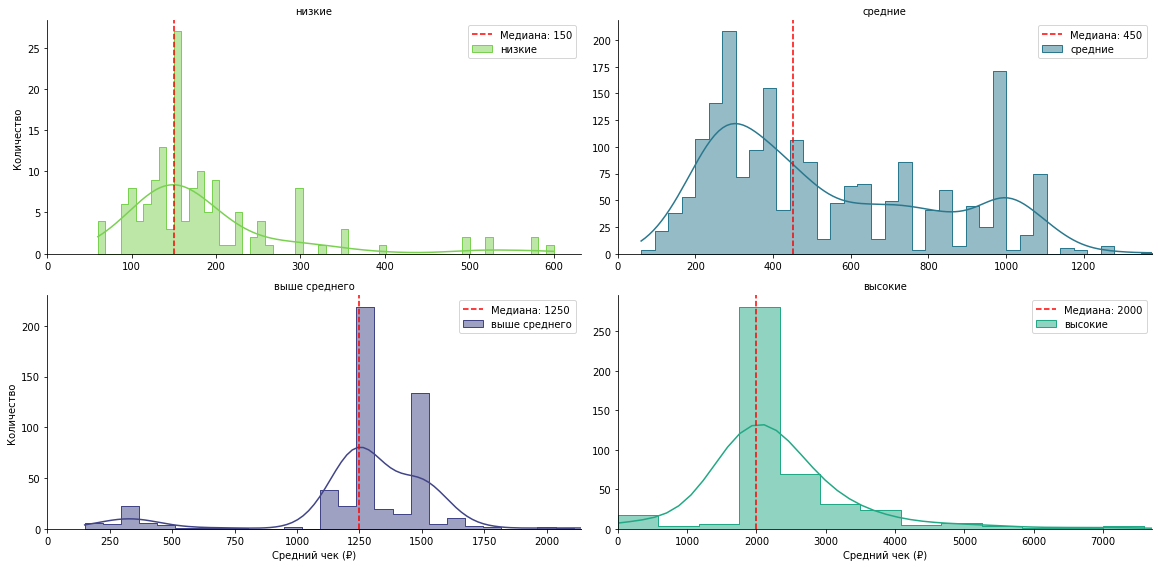

In [45]:
plot_data = rest_df[['corrected_avg_bill', 'price']].dropna()
plot_data['corrected_avg_bill'] = plot_data['corrected_avg_bill'].astype(float)
price_order = ['низкие', 'средние', 'выше среднего', 'высокие']

# 2. Создаем сетку (БЕЗ plt.subplots)
# col_wrap=2 сделает сетку 2x2, чтобы графики были крупнее
g = sns.FacetGrid(plot_data, col="price", col_order=price_order, 
                  hue="price", palette="viridis", height=4, aspect=2, 
                  sharex=False, sharey=False, col_wrap=2)

# 3. Добавляем гистограммы
g.map(sns.histplot, "corrected_avg_bill", bins=60, kde=True, element="step")

# 4. Тюнинг осей и медиан
for ax, p_cat in zip(g.axes.flat, price_order):
    # Берем срез данных для конкретной категории
    subset = plot_data[plot_data['price'] == p_cat]['corrected_avg_bill']
    
    if not subset.empty:
        median_val = subset.median()
        ax.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.0f}')
        
        # Ограничиваем X, чтобы выбросы (как те 35к) не сжимали график
        upper_limit = subset.quantile(0.99)
        ax.set_xlim(0, upper_limit * 1.1)
        
        ax.legend()

# 5. Оформление заголовков
g.set_titles("{col_name}")
g.set_axis_labels("Средний чек (₽)", "Количество")

✅ Теперь заполним **пропуски corrected_avg_bill** медианой по группе price, если она указана в строке.

In [46]:
bill_medians = rest_df.groupby('price')['corrected_avg_bill'].transform('median')
rest_df['corrected_avg_bill'] = rest_df['corrected_avg_bill'].fillna(bill_medians).astype('Int32')

In [47]:
print('Пропусков bill:', rest_df['corrected_avg_bill'].isna().sum())
print('Пропусков price:', rest_df['price'].isna().sum())
print('Пропусков bill и price одновременно:', 
      len(rest_df[rest_df['corrected_avg_bill'].isna() & rest_df['price'].isna()]))
print('Пропусков price с заполненным bill:', 
      len(rest_df[~rest_df['corrected_avg_bill'].isna() & rest_df['price'].isna()]))

Пропусков bill: 4344
Пропусков price: 5087
Пропусков bill и price одновременно: 4344
Пропусков price с заполненным bill: 743


✅ Теперь в обратном направлении: заполним пропущенные категории price в строках, где имеется corrected_avg_bill. 
Категорию price подберём по близости к медиане категории.

In [48]:
price_medians = rest_df.groupby('price')['corrected_avg_bill'].median().dropna()
# будем обрабатывать только строки, где есть corrected_avg_bill, но нет price
price_mask = rest_df['price'].isna() & rest_df['corrected_avg_bill'].notna()

rest_df.loc[price_mask, 'price'] = rest_df.loc[price_mask, 'corrected_avg_bill'].map(
    # находим категорию price с ближайшей в avg_bill медианой
    lambda val: (price_medians - val).sort_values().index[0]
)

In [49]:
print('Пропусков bill:', rest_df['corrected_avg_bill'].isna().sum())
print('Заполнено bill:', rest_df['corrected_avg_bill'].notna().sum())
print('Пропусков price:', rest_df['price'].isna().sum())
print('Пропусков bill и price одновременно:', 
      len(rest_df[rest_df['corrected_avg_bill'].isna() & rest_df['price'].isna()]))
print('Пропусков price с заполненным bill:', 
      len(rest_df[~rest_df['corrected_avg_bill'].isna() & rest_df['price'].isna()]))
print(f'Разница: исходное число точек ({rest_info_df_shape[0]}) - пропуски цен =', rest_info_df_shape[0] - rest_df['corrected_avg_bill'].isna().sum())
print('Исходное число цен:', rest_price_df_shape[0])

Пропусков bill: 4344
Заполнено bill: 4058
Пропусков price: 4344
Пропусков bill и price одновременно: 4344
Пропусков price с заполненным bill: 0
Разница: исходное число точек (8406) - пропуски цен = 4062
Исходное число цен: 4058


👉 Теперь из второго датасета с ценами выжато максимум, что в нём есть: заполнили corrected_avg_bill и price как могли, используя все доступные данные. И теперь мы видим, что у нас исходно было **4058** строк данных по уникальным id точек питания, и сейчас 4058 строк имеют заполненный corrected_avg_bill и price двунаправленным методом!

In [50]:
 display(get_missing_values_statistics(rest_df))

,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
middle_coffee_cup,7867,93.63
middle_avg_bill,5253,62.52
avg_bill,4586,54.58
avg_bill_type,4586,54.58
price,4344,51.70
corrected_avg_bill,4344,51.70
hours,535,6.37


Мы видим, что пропуски почти исключительно в данных из второго датасета, но они соотвествуют разнице числа строк первого и второго датасета: она ~50%.

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

- Установлены индексы датасетов по id точки питания;
- проведена нормализация значений по пробелам и регистру;
- проверены значения столбцов на пропуски, маркеры пропусков;
- колонки приведены к оптимальным расширенным типам данных pandas;
- для анализа удалённости district добавлено поле **distance = 0, 1, 2**;
- датасеты объединены по индексам на id через left join, главный датасет rest_info;
- данные проверены на явные дубликаты, удалено 0.05% строк;
- добавлены колонки для анализа: **is_24_7, avg_bill_type = средний счёт, цена чашки капучино, ена бокала пива**;
- проанализировано поле seats: в нём сильные выбросы;
- исправлены пропуски в seats медианами по группам (category, district);
- добавлена категориальная колонка **seats_type = 0, 1, 2**;
- для анализа надо использовать seats_type = 1;
- проверен rating, найден много выбросов слева, для анализа добавлено категорийное поле **rating_cat = Низкая", "Средняя", "Высокая", "Очень высокая"**, но может понадобится дробление в области 4 - 4.6, где сосредоточено очень много рейтингов;
- проверены безымянные кафе, ни на что не влияют;
- проверен адрес, где зарегистрировано 28 кафе: это норма, там Парк фуд холл;
- проверены price и avg_bill, добавлена колонка **corrected_avg_bill**, в которой заполнены данные о среднем чеке по всем строкам из второго датасета при помощи медианы по price в двух направлениях;
- проверен средний чек по категории price: много выбросов и категории пересекаются, но есть чёткие медианы.

## 3. Исследовательский анализ данных

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

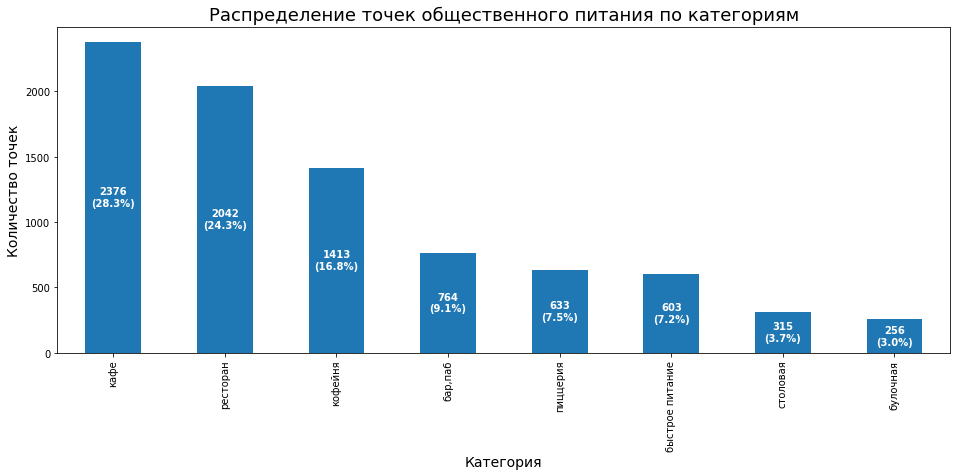

In [51]:
rest_cats = rest_df['category'].value_counts()
total_points = rest_cats.sum()

ax = rest_cats.plot(figsize=(16, 6), kind='bar')
ax.set_title('Распределение точек общественного питания по категориям', fontsize=18)
ax.set_ylabel('Количество точек', fontsize=14)
ax.set_xlabel('Категория', fontsize=14)


rest_labels = [f'{val}\n({val / total_points:.1%})' for val in rest_cats]
ax.bar_label(ax.containers[0], labels=rest_labels, label_type='center', color='white', fontweight='bold')

plt.show()

👉 Видим, 8 категорий. Среди них мало булочных (3%), основные точки это три типа: **кафе, кафейни и рестораны (всего 68%)**. Пицерий и фастфуда почти поровну (по 7%).Классических столовых 4%.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

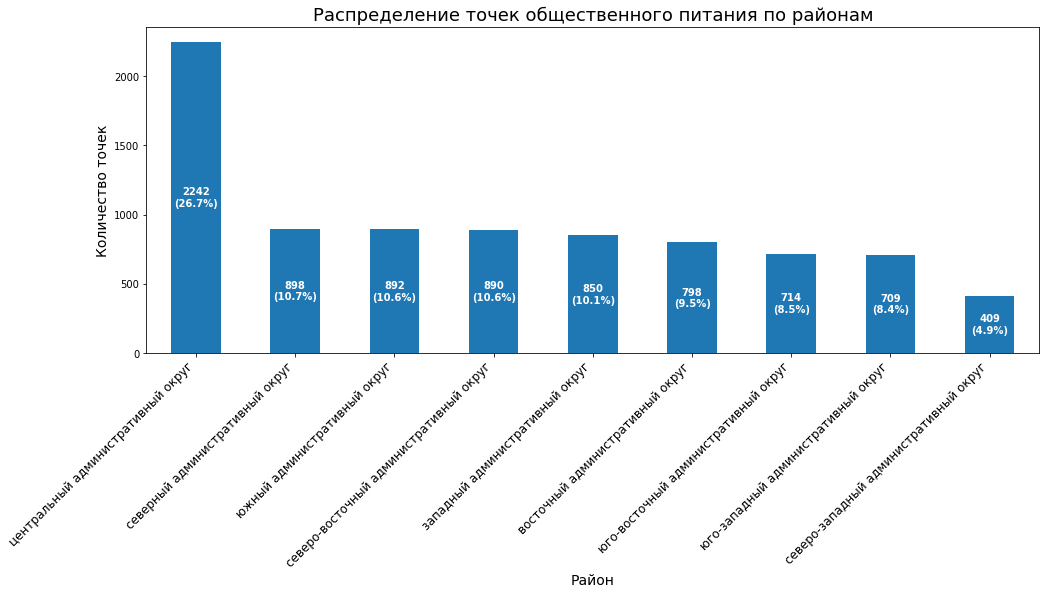

In [52]:
rest_cats = rest_df['district'].value_counts()
total_points = rest_cats.sum()

ax = rest_cats.plot(figsize=(16, 6), kind='bar')
ax.set_title('Распределение точек общественного питания по районам', fontsize=18)
ax.set_ylabel('Количество точек', fontsize=14)
ax.set_xlabel('Район', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)


rest_labels = [f'{val}\n({val / total_points:.1%})' for val in rest_cats]
ax.bar_label(ax.containers[0], labels=rest_labels, label_type='center', color='white', fontweight='bold')

plt.show()

👉 Видим, что в ЦАО больше всего точек питания (26%), на Северо-западе меньше всего (5%), в остальных районах примерно по 10%.

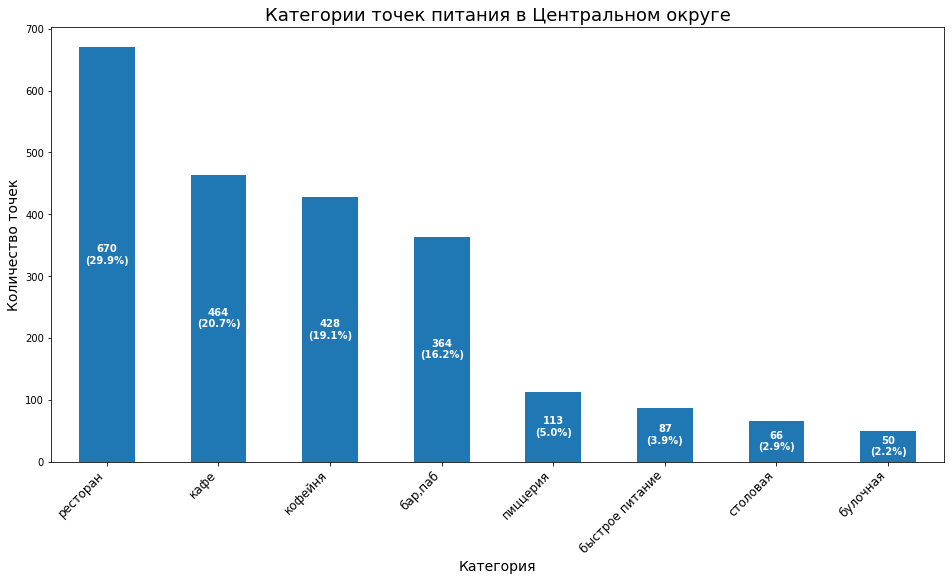

In [53]:
central_mask = rest_df['district'].str.contains('центральный', na=False)
central_df = rest_df[central_mask]

central_cats = central_df['category'].value_counts()
total_points = central_cats.sum()

ax = central_cats.plot(kind='bar', figsize=(16, 8))
ax.set_title('Категории точек питания в Центральном округе', fontsize=18)
ax.set_xlabel('Категория', fontsize=14)
ax.set_ylabel('Количество точек', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

rest_labels = [f'{val}\n({val / total_points:.1%})' for val in central_cats]
ax.bar_label(ax.containers[0], labels=rest_labels, label_type='center', color='white', fontweight='bold')

plt.show()

👉 Распределение в ЦАО по типам точек похоже на среднее по районам, но **выше доля Пабов**: 16% против 9% по городу вцелом. В 2 раза меньше доля быстрого питания и столовых. Но вот ресторанов почти столько же: 30%.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

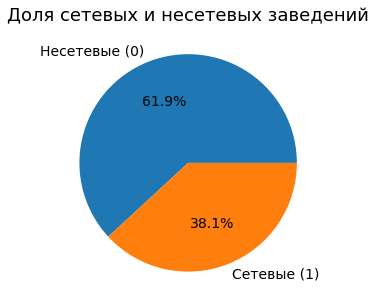

In [54]:
chain_counts = rest_df['chain'].value_counts().sort_index()
chain_counts.index = ['Несетевые (0)', 'Сетевые (1)']

chain_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='',
    figsize=(5, 5),
    textprops={'fontsize': 14},    
)

plt.title('Доля сетевых и несетевых заведений', fontsize=18)
plt.show()

👉 Среди всех точек по Москве сетевых меньшинство: 38%.

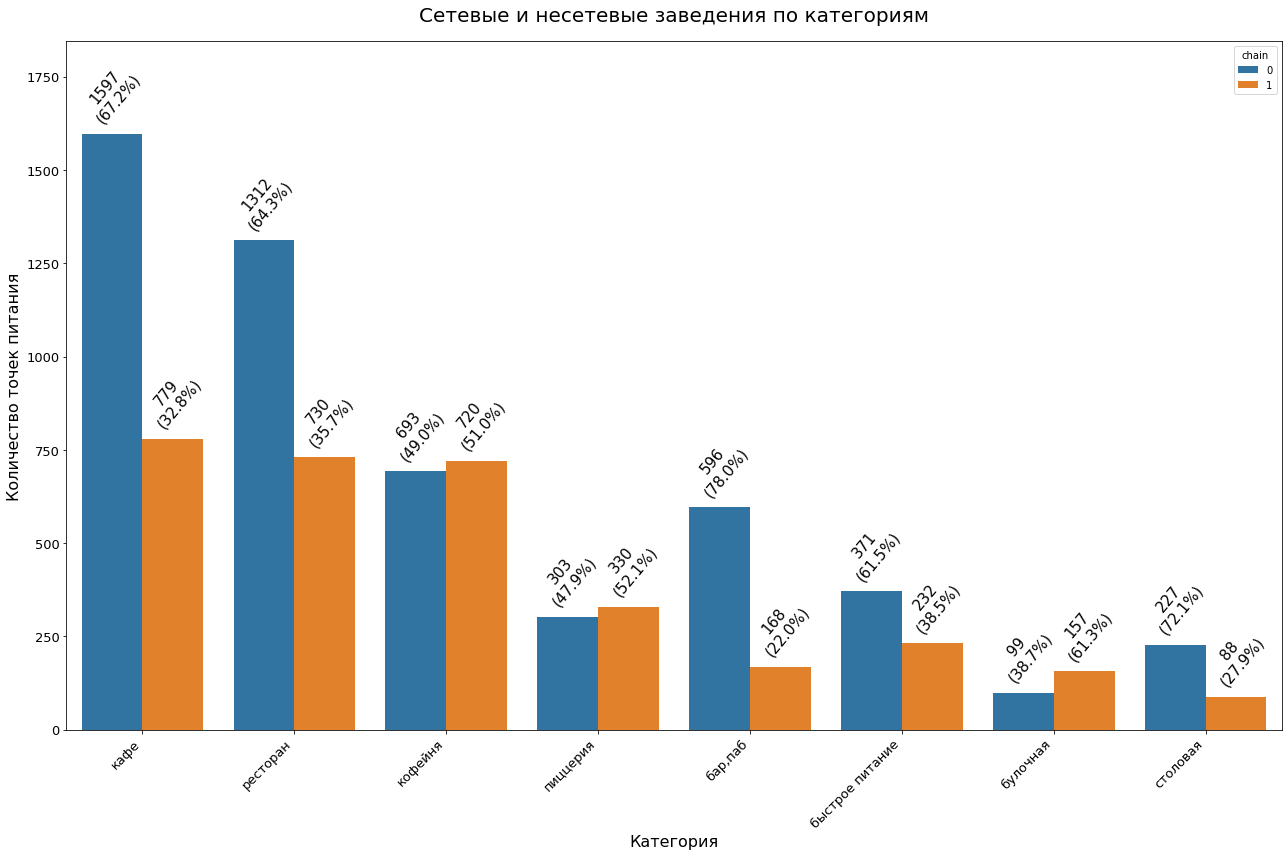

In [55]:
plt.figure(figsize=(18, 12))
ax = sns.countplot(data=rest_df, x='category', hue='chain')

c1_heights = [float(bar.get_height() or 0) for bar in ax.containers[0]]
c2_heights = [float(bar.get_height() or 0) for bar in ax.containers[1]]
category_sums = [h1 + h2 for h1, h2 in zip(c1_heights, c2_heights)]

for container in ax.containers:
    labels = []
    for i, bar in enumerate(container):
        height = float(bar.get_height() or 0)
        total_in_cat = category_sums[i]
        
        if height > 0 and total_in_cat > 0:
            percent = height / total_in_cat
            labels.append(f'{int(height)}\n({percent:.1%})')
        else:
            labels.append('')
    
    texts = ax.bar_label(container, labels=labels, fontsize=15, padding=8)
    for t in texts:
        t.set_rotation(50)        

ax.set_title('Сетевые и несетевые заведения по категориям', fontsize=20, pad=20)
ax.set_xlabel('Категория', fontsize=16)
ax.set_ylabel('Количество точек питания', fontsize=16)

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

👉 По категориям видим, что среди кофеен, пиццерий и булочных сетевых точек больше (51+ %), а вот среди пабов только 22% и 27% среди столовых.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


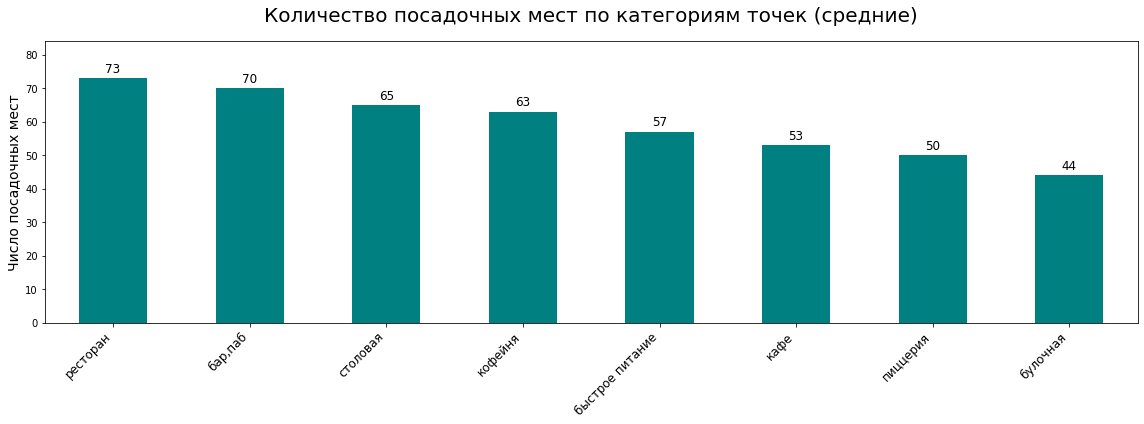

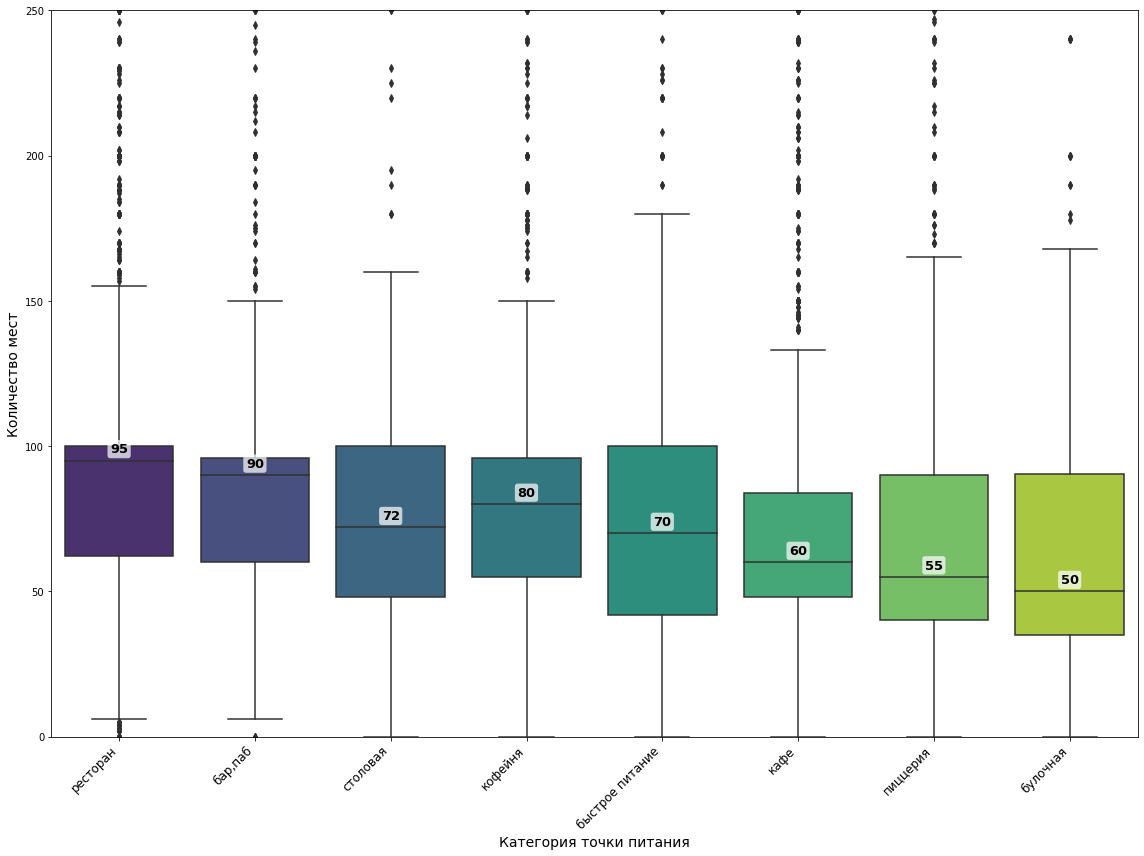

In [180]:
# seats_median = rest_df.groupby('category')['seats'].mean()
# Много выбросов справа, длинный хвост, поэтому, пробую их отбросить и сместить средние вниз (влево) seats_type=0, 1
seats_median_src = rest_df[(rest_df['seats_type'] == 1) | (rest_df['seats_type'] == 0)].groupby('category')['seats'].mean()
seats_median = seats_median_src.astype(float).round().astype(int).sort_values(ascending=False)

ax = seats_median.plot(figsize=(16, 6), kind='bar', color='teal')

ax.set_title('Количество посадочных мест по категориям точек (средние)', fontsize=20, pad=20)
ax.set_ylabel('Число посадочных мест', fontsize=14)
# ax.set_xlabel('Категория точки питания', fontsize=14)
ax.set_xlabel('')

ax.bar_label(ax.containers[0], fontsize=12, padding=3)

plt.xticks(rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, seats_median.max() * 1.15)

plt.tight_layout()
plt.show()

# Ящик с усами для оценки выбросов
order = seats_median.index

plt.figure(figsize=(16, 12))

ax = sns.boxplot(
    data=rest_df, 
    x='category', 
    y=rest_df['seats'].astype(float), 
    order=order, 
    palette='viridis'
)

medians_tmp = rest_df.groupby('category')['seats'].median().loc[order]
for i, median in enumerate(medians_tmp):
    ax.annotate(
        f'{median:.0f}', 
        xy=(i, median), 
        xytext=(0, 5),          # Смещение чуть выше линии медианы
        textcoords='offset points', 
        ha='center', va='bottom', 
        fontsize=13, 
        fontweight='bold', 
        color='black',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none') # Светлая подложка
    )

# ax.set_title('Распределение посадочных мест по категориям точек', fontsize=20, pad=20)
ax.set_ylabel('Количество мест', fontsize=14)
ax.set_xlabel('Категория точки питания', fontsize=14)

ax.set_ylim(0, 250) 

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

👉 Данные по seats некачественные: они с большим числом выбросов справа. Это из-за недостаточной разбивки точек питания на категории. Она грубая. Есть точки на вынос, ларьки, где нет посадочных мест или 1-2 стойки. И есть банкетные залы на тысячи мест. Но они в общих сегментах. Чтобы увидеть достоверные значения, я отображаю средние по category с учётом seats_type. Пробовал разные варианты. Медиану тоже.
В целом, больше всего мест в ресторанах (73) и меньше в пицериях и булочных (50 и 44). Среднее в кофейнях (63). Снижение почти линейное.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

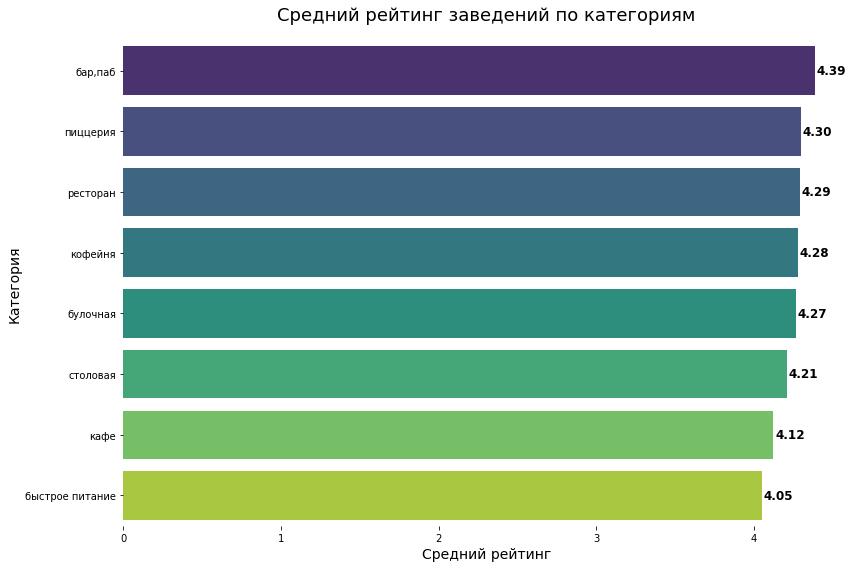

In [57]:
avg_rating_by_category = rest_df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=avg_rating_by_category.values,
    y=avg_rating_by_category.index,
    palette='viridis'
)
ax.set_title('Средний рейтинг заведений по категориям', fontsize=18, pad=20)
ax.set_xlabel('Средний рейтинг', fontsize=14)
ax.set_ylabel('Категория', fontsize=14)

# Добавление значений на столбцы
for i, (category, rating) in enumerate(avg_rating_by_category.items()):
    ax.text(rating + 0.01, i, f'{rating:.2f}', 
            va='center', ha='left', fontsize=12, color='black', weight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

👉 Рейтинги смещены в область 4 - 4.5, масимальные у баров, пиццерий и ресторанов, минимальные у фастфуда и кафе. Можно ещё отобразить рейтинг по категориям.

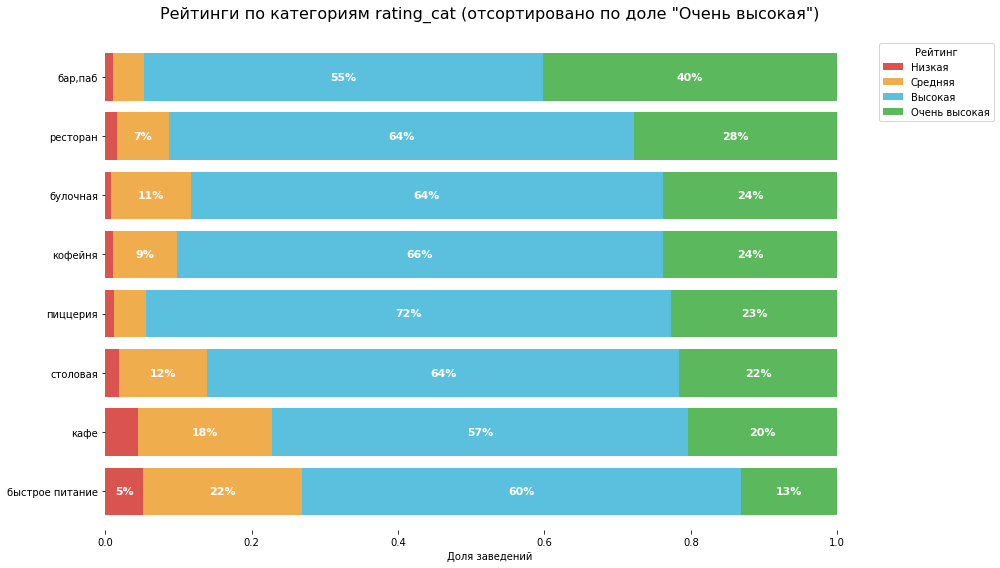

In [186]:
order = ['Низкая', 'Средняя', 'Высокая', 'Очень высокая']
cross_tab = pd.crosstab(rest_df['category'], rest_df['rating_cat'], normalize='index')
cols = [c for c in order if c in cross_tab.columns]

# Сортировка по возрастанию доли "Очень высокая"
cross_tab = cross_tab[cols].sort_values(by='Очень высокая', ascending=True)

colors = {'Низкая': '#d9534f', 'Средняя': '#f0ad4e', 'Высокая': '#5bc0de', 'Очень высокая': '#5cb85c'}
ax = cross_tab.plot(kind='barh', stacked=True, figsize=(14, 8), 
                    color=[colors[c] for c in cross_tab.columns], width=0.8)

for c in ax.containers:
    labels = [f'{v.get_width():.0%}' if v.get_width() > 0.05 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold', fontsize=11)

ax.set_title('Рейтинги по категориям rating_cat (отсортировано по доле "Очень высокая")', fontsize=16, pad=20)
ax.set_xlabel('Доля заведений')
ax.set_ylabel('')
ax.legend(title='Рейтинг', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

👉 Тут видно, что у пабов и ресторанов самые высокие доли сегментов с высоким рейтингов (40 и 28%), а среди кафе и фастфудов доли трешовых точек 5%.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

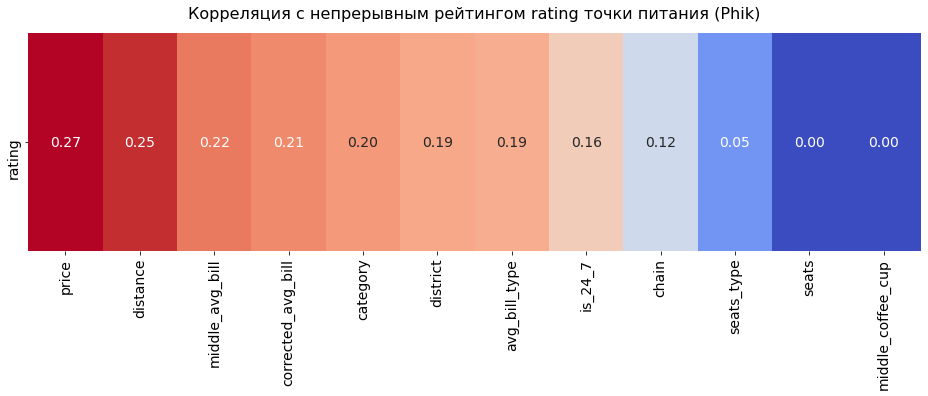

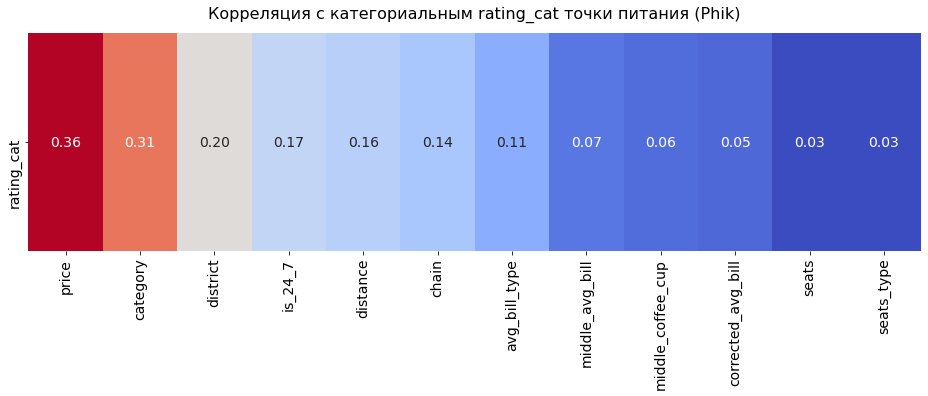

In [187]:
cols = [
    'rating', 'category', 'district', 'chain', 
    'seats', 'is_24_7', 'seats_type', 'corrected_avg_bill',
    'distance', 'rating_cat', 'avg_bill_type', 'price', 'middle_coffee_cup', 'middle_avg_bill',
]
interval_cols = ['rating', 'seats', 'corrected_avg_bill', 'distance', 'middle_coffee_cup', 'middle_avg_bill']

def show_phink_matrix_in(df, cols, interval_cols, name, drop_names):
    pm = df[cols].phik_matrix(interval_cols=interval_cols)
    rating_corrs = pm[name].sort_values(ascending=False)
    # транспонируем, чтобы рисовалось слева на право
    plot_data = rating_corrs.to_frame().drop(drop_names).T

    plt.figure(figsize=(16, 4))
    ax = sns.heatmap(plot_data, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, annot_kws={'size': 14})
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.ylabel('')
        
    return plt, rating_corrs

        
plt, matrix = show_phink_matrix_in(rest_df, cols, interval_cols, 'rating', ['rating', 'rating_cat'])
plt.title('Корреляция с непрерывным рейтингом rating точки питания (Phik)', fontsize=16, pad=15)
plt.show()

plt, matrix = show_phink_matrix_in(rest_df, cols, interval_cols, 'rating_cat', ['rating', 'rating_cat'])
plt.title('Корреляция с категориальным rating_cat точки питания (Phik)', fontsize=16, pad=15)
plt.show()


👉 После анализа корреляции стало ясно, что добавленные производные категорийные атрибуты помогают её выявить. Наибольшая корреляция рейтинга точки питания оказалась с ценовой категорией (**price**), расстоянием от центра (**distance**), типом точки (**category**). Как ни странно, avg_bill после пересоздания даже ухудшился, middle_avg_bill чуть лучше корелирован. Атрибут distance очень помог выявить связь district и рейтинга. И есть небольшая корреляция между is_24_7 и chain. А вот размер зала не влияет на рейтинг. Теперь детально посмотрим на каждую и сильных кореляций.

Ещё, мы видим, что для категорийного рейтинга rating_cat корреляции сильнее, но приоритеты немного другие. Оба подхода ставят на первое место price, distance, category.

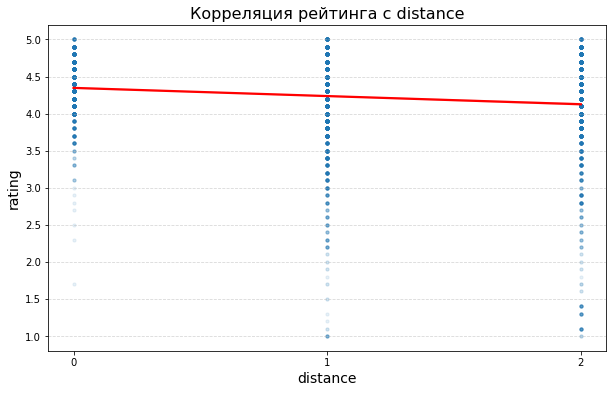

In [66]:
viz_df = rest_df.copy()

# Конвертируем числовые столбцы из типов Pandas в стандартный float
for col in interval_cols:    
    viz_df[col] = viz_df[col].astype(float)
    
plt.figure(figsize=(10, 6))
ax = sns.regplot(
    data=viz_df, 
    x='distance', 
    y='rating', 
    scatter_kws={'alpha': 0.1, 's': 10}, 
    line_kws={'color': 'red'}
)

# отступы по 5% диапазона данных
xmin, xmax = viz_df['distance'].min(), viz_df['distance'].max()
dx = (xmax - xmin) * 0.05
ymin, ymax = viz_df['rating'].min(), viz_df['rating'].max()
dy = (ymax - ymin) * 0.05

ax.set_xlim(xmin - dx, xmax + dx)
ax.set_ylim(ymin - dy, ymax + dy)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.grid(True, which='major', linestyle='--', alpha=0.5)

plt.title('Корреляция рейтинга с distance', fontsize=16)
ax.set_xlabel('distance', fontsize=14)
ax.set_ylabel('rating', fontsize=14)
plt.show()



👉 По удалению от центра у нас производное поле **distance: 0 - центр, 1 - горизонталь или вертикаль от центра, 2 - диагональ**. Видим, что **корреляция отрицательная** phik = -0.25: Юго-запад, Юго-восток, Северо-запад и Северо-восток - снижают рейтинг. Наибольший рейтинг в центре.

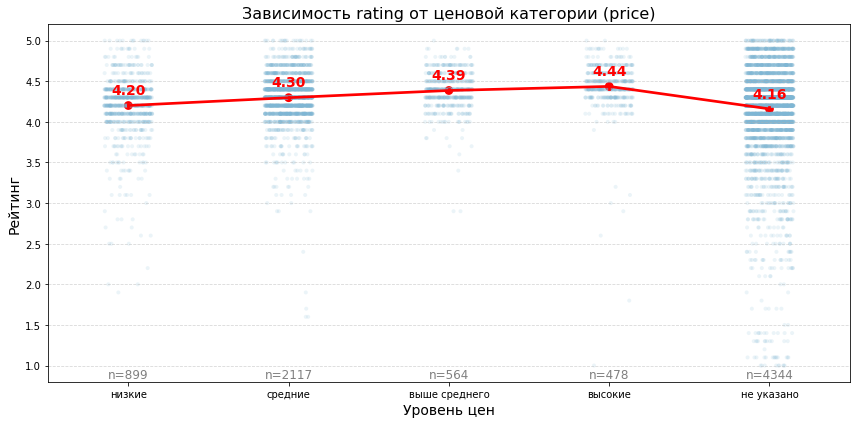

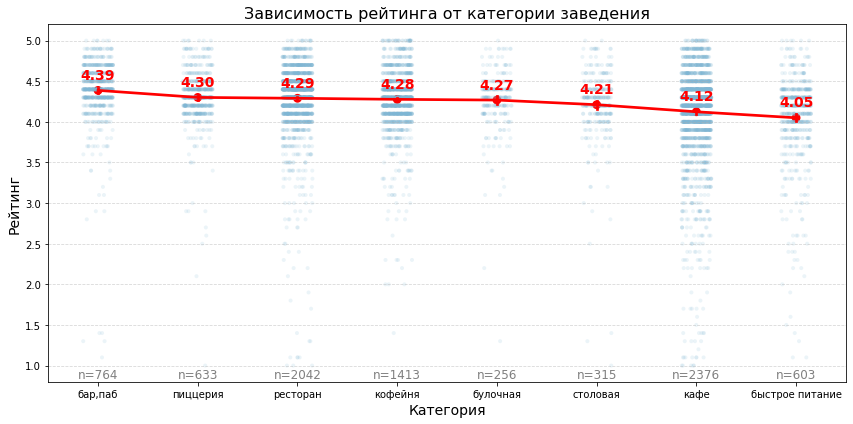

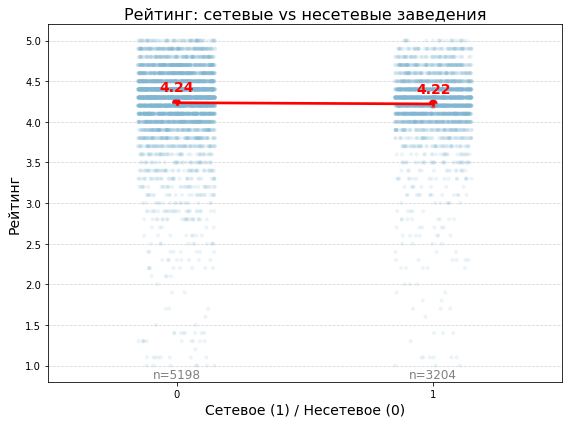

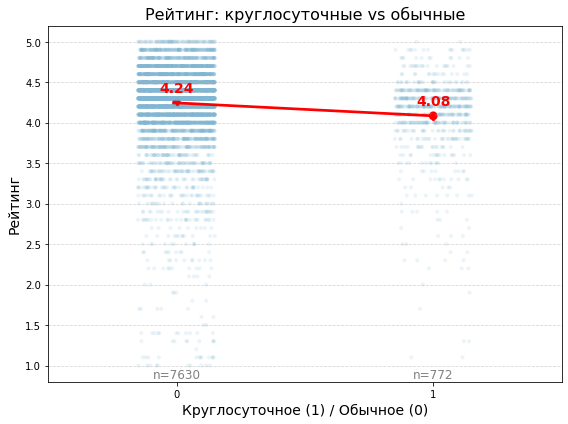

In [124]:
def plot_rating_by_category(df, column, order=None, title=None, xlabel=None, figsize=(12, 6)):
    
    # Копируем данные и заполняем пропуски
    viz_df = df.copy()
    col_vis = f'{column}_vis'
    
    if viz_df[column].dtype == 'string' or viz_df[column].dtype == 'object':
        viz_df[col_vis] = viz_df[column].fillna('не указано')
    else:
        viz_df[col_vis] = viz_df[column].fillna('не указано').astype(str)
    
    # Определяем порядок категорий
    if order is None:
        # По умолчанию: сортировка по убыванию среднего рейтинга
        order = viz_df.groupby(col_vis)['rating'].mean().sort_values(ascending=False).index.tolist()
        
        # Перемещаем 'не указано' в конец, если есть
        if 'не указано' in order:
            order.remove('не указано')
            order.append('не указано')
    
    # Создаем фигуру
    plt.figure(figsize=figsize)
    
    # Основной график: линия средних значений
    ax = sns.pointplot(
        data=viz_df,
        x=col_vis,
        y='rating',
        order=order,
        errorbar=None,
        markers='o',
        linestyles='-',
        color='red',
        zorder=2
    )
    
    # Добавляем точки распределения
    sns.stripplot(
        data=viz_df,
        x=col_vis,
        y='rating',
        order=order,
        alpha=0.15,
        size=4,
        jitter=0.15,
        color='#7EB6D4',
        ax=ax,
        zorder=1
    )
    
    # Настройка отступов по Y
    ymin, ymax = viz_df['rating'].min(), viz_df['rating'].max()
    dy = (ymax - ymin) * 0.05
    ax.set_ylim(ymin - dy, ymax + dy)
    
    # Сетка и подписи
    ax.yaxis.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.set_xlabel(xlabel if xlabel else column, fontsize=14)
    ax.set_ylabel('Рейтинг', fontsize=14)
    plt.title(title if title else f'Зависимость rating от {column}', fontsize=16)
    
    # Добавляем значения средних и количество записей
    for i, cat in enumerate(order):
        data_subset = viz_df[viz_df[col_vis] == cat]['rating']
        if len(data_subset) > 0:
            mean_val = data_subset.mean()
            count = len(data_subset)
            
            # Среднее значение над точкой
            ax.text(i, mean_val + 0.1, f'{mean_val:.2f}',
                    ha='center', va='bottom', fontweight='bold', 
                    fontsize=14, color='red')
            
            # Количество под осью X
            ax.text(i, ymin - dy * 0.15, f'n={count}',
                    ha='center', va='top', fontsize=12, color='gray')
    
    plt.tight_layout()
    plt.show()


price_order = ['низкие', 'средние', 'выше среднего', 'высокие', 'не указано']

plot_rating_by_category(
    df=rest_df,
    column='price',
    order=price_order,
    title='Зависимость rating от ценовой категории (price)',
    xlabel='Уровень цен'
)

plot_rating_by_category(
    df=rest_df,
    column='category',
    title='Зависимость рейтинга от категории заведения',
    xlabel='Категория'    
)

plot_rating_by_category(
    df=rest_df,
    column='chain',
    title='Рейтинг: сетевые vs несетевые заведения',
    xlabel='Сетевое (1) / Несетевое (0)',
    figsize=(8, 6)
)

plot_rating_by_category(
    df=rest_df,
    column='is_24_7',
    order=['0', '1'],
    title='Рейтинг: круглосуточные vs обычные',
    xlabel='Круглосуточное (1) / Обычное (0)',
    figsize=(8, 6)
)

👉 Тут видим, что **корреляция положительная** (phik=0.27): при увеличении ценовой категории рейтинг растёт. Наиболее чёткий рейтинг с минимальными выбросами в сегменте **Выше среднего**. В данных, где нет сегмента по цене, рейтинг ниже и большой разброс оценок.

По **category** видим, что рейтинг пабов высокий, а фастфуда ниже всего.
Принадлежность к сети почти не влияет, а круглосуточность снижает рейтинг.

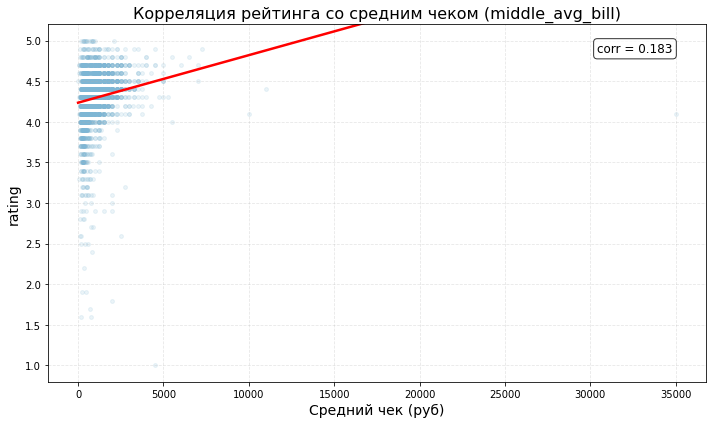

In [126]:
def plot_rating_scatter(df, column, title=None, xlabel=None, figsize=(10, 6)):
    """
    Простой scatter plot с регрессией.
    """
    viz_df = df.copy()
    
    # Конвертируем в float
    viz_df[column] = pd.to_numeric(viz_df[column], errors='coerce')
    viz_df['rating'] = pd.to_numeric(viz_df['rating'], errors='coerce')
    plot_data = viz_df[[column, 'rating']].dropna()
    
    # Принудительно в numpy массивы
    x = plot_data[column].to_numpy(dtype=float)
    y = plot_data['rating'].to_numpy(dtype=float)
    
    plt.figure(figsize=figsize)
    
    # Простой scatter
    plt.scatter(x, y, alpha=0.15, s=15, c='#7EB6D4')
    
    # Линейная регрессия через numpy (без seaborn)
    coeffs = np.polyfit(x, y, 1)
    poly_eq = np.poly1d(coeffs)
    x_line = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_line, poly_eq(x_line), color='red', linewidth=2.5)
    
    # Отступы
    xmin, xmax = x.min(), x.max()
    dx = (xmax - xmin) * 0.05
    ymin, ymax = y.min(), y.max()
    dy = (ymax - ymin) * 0.05
    
    plt.xlim(xmin - dx, xmax + dx)
    plt.ylim(ymin - dy, ymax + dy)
    
    plt.grid(True, which='major', linestyle='--', alpha=0.3)
    plt.title(title if title else f'Корреляция рейтинга с {column}', fontsize=16)
    plt.xlabel(xlabel if xlabel else column, fontsize=14)
    plt.ylabel('rating', fontsize=14)
    
    # Корреляция
    corr = np.corrcoef(x, y)[0, 1]
    plt.text(0.95, 0.95, f'corr = {corr:.3f}', 
             transform=plt.gca().transAxes, ha='right', va='top',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Использование
plot_rating_scatter(
    df=rest_df,
    column='middle_avg_bill',
    title='Корреляция рейтинга со средним чеком (middle_avg_bill)',
    xlabel='Средний чек (руб)'
)

👉 По сырому среднему чеку видим, что корреляция положительная и в дорогих точках рейтинг выше.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [146]:
chains_stats = rest_df.query('chain == 1').groupby('name').agg(
    count=('name', 'count'),
    avg_rating=('rating', 'mean'),
    median_rating=('rating', 'median'),
    min_price=('price', lambda x: x.mode().iloc[0] if not x.mode().empty else 'нет данных'),
    avg_bill_mean=('middle_avg_bill', 'mean'),
    avg_bill_mean_corr=('corrected_avg_bill', 'mean')
).reset_index()

top_15_chains = chains_stats.sort_values('count', ascending=False).head(15)

# Форматируем для красивого вывода
styled = top_15_chains.style.format({
    'avg_rating': '{:.2f}',
    'median_rating': '{:.2f}',        
    'avg_bill_mean': lambda x: f'{x:.2f} ₽' if pd.notna(x) else '—',
    'avg_bill_mean_corr': lambda x: f'{x:.2f} ₽' if pd.notna(x) else '—'
})

display(styled)

,name,count,avg_rating,median_rating,min_price,avg_bill_mean,avg_bill_mean_corr
729,шоколадница,120,4.18,4.20,средние,679.17 ₽,342.42 ₽
335,домино'с пицца,76,4.17,4.20,средние,503.57 ₽,472.18 ₽
331,додо пицца,74,4.29,4.30,низкие,388.26 ₽,388.26 ₽
146,one price coffee,71,4.06,4.20,низкие,—,145.71 ₽
742,яндекс лавка,69,3.87,4.00,нет данных,—,—
58,cofix,65,4.08,4.10,низкие,—,68.57 ₽
168,prime,50,4.12,4.20,средние,362.00 ₽,365.38 ₽
664,хинкальная,44,4.32,4.40,средние,1005.26 ₽,943.48 ₽
409,кофепорт,42,4.15,4.20,низкие,—,95.83 ₽
418,кулинарная лавка братьев караваевых,39,4.39,4.40,средние,460.69 ₽,460.00 ₽


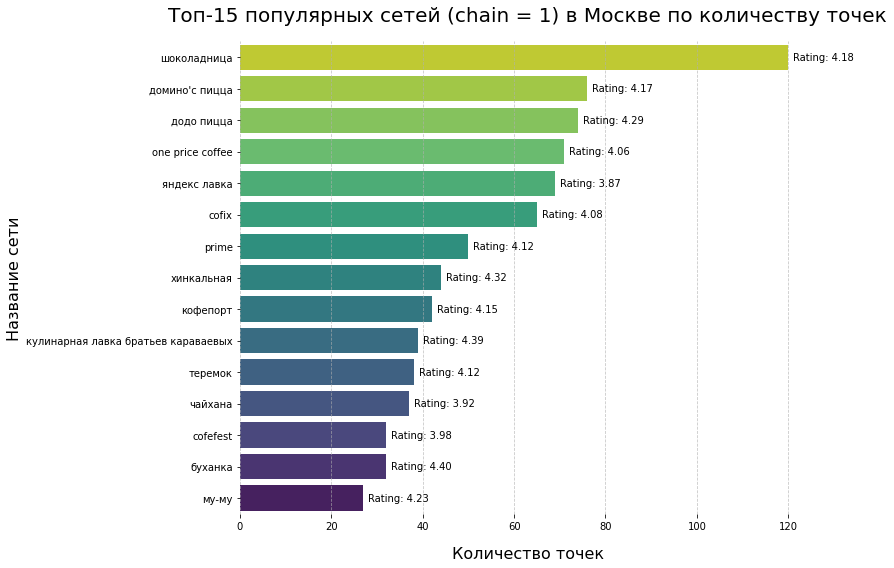

In [150]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=top_15_chains, x='count', y='name', palette='viridis_r')

# Добавляем подписи среднего рейтинга на бары
for i, p in enumerate(ax.patches):
    rating = top_15_chains.iloc[i]['avg_rating']
    ax.annotate(f'Rating: {rating:.2f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=10)

plt.title('Топ-15 популярных сетей (chain = 1) в Москве по количеству точек', fontsize=20, pad=20)
plt.xlabel('Количество точек', fontsize=16, labelpad=15)
plt.ylabel('Название сети', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

👉 Из сетьевых точек самые популярные Шоколодница, Доминос и Додо пицца. Первая идёт с большим отрывом от всех: 120 точек, у остальных ~70. Наименее популярная Му-му. При этом рейтинг у Шоколадницы отстаёт: 4.18 против 4.40 у Буханки.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


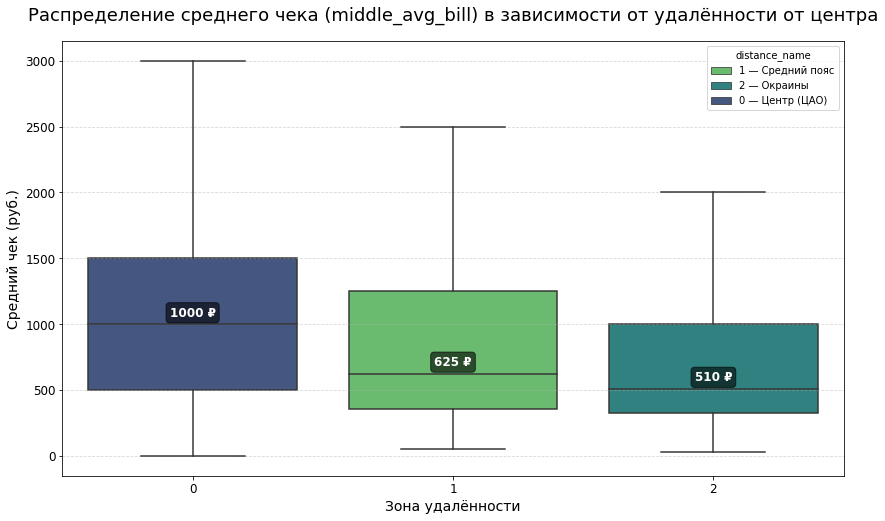

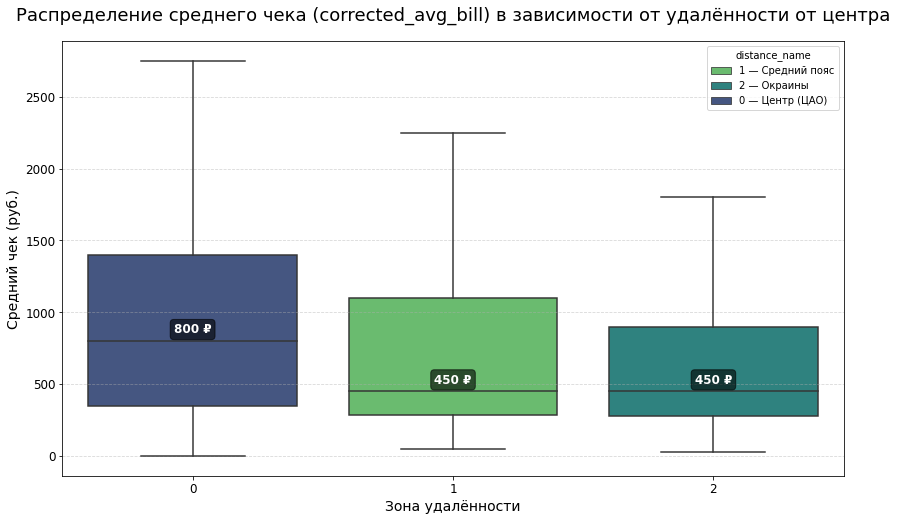

In [169]:
distance_labels = {0: '0 — Центр (ЦАО)', 1: '1 — Средний пояс', 2: '2 — Окраины'}
rest_df['distance_name'] = rest_df['distance'].map(distance_labels)

def plot_avg_bill_boxes(name):
    plt.figure(figsize=(14, 8))
    ax = sns.boxplot(data=rest_df, x='distance', y=name, palette='viridis_r', showfliers=False,
                hue='distance_name',
                dodge=False 
               )
    
    medians = rest_df.groupby('distance')[name].median()
    
    # Наносим медианы текстом на ящики
    for i, median in enumerate(medians):
        # i — это координата X (0, 1, 2), median — координата Y
        ax.annotate(f'{median:.0f} ₽', 
                    xy=(i, median), 
                    xytext=(0, 5),             # Смещение текста чуть выше линии медианы
                    textcoords='offset points', 
                    ha='center', va='bottom', 
                    fontsize=12, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

    plt.title(f'Распределение среднего чека ({name}) в зависимости от удалённости от центра', fontsize=18, pad=20)
    plt.xlabel('Зона удалённости', fontsize=14)
    plt.ylabel('Средний чек (руб.)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    plt.show()
    


plot_avg_bill_boxes('middle_avg_bill')
plot_avg_bill_boxes('corrected_avg_bill')

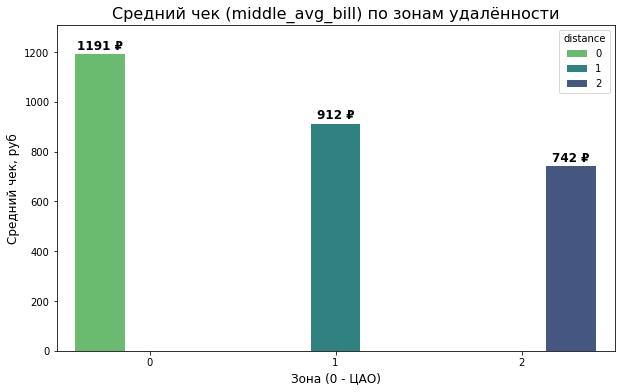

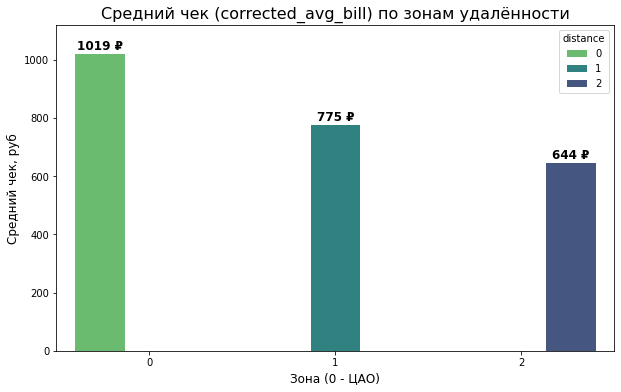

In [166]:
def plot_avg_bill_bar(name):
    dist_stats = rest_df.groupby('distance')[name].mean().reset_index()

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=dist_stats, x='distance', y=name, palette='viridis_r', hue='distance')
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f} ₽', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=12, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

    plt.title(f'Средний чек ({name}) по зонам удалённости', fontsize=16)
    plt.xlabel('Зона (0 - ЦАО)', fontsize=12)
    plt.ylabel('Средний чек, руб', fontsize=12)
    plt.ylim(0, dist_stats[name].max() * 1.1) # Запас места сверху под текст
    plt.show()

plot_avg_bill_bar('middle_avg_bill')
plot_avg_bill_bar('corrected_avg_bill')

👉 Средние чеки похоже корректней брать corrected_avg_bill. Мы видим, что в центре средний чек 1019 при медиане **800**. Это говорит о наличии выбросов. Окраины я посчитал по диагонали от центра (категория 2), и мы видим, что там средний чек 644 при медиане **450**. В данных много выбросов по крупным цифрам. Поэтому, ориентироваться можно на мидиану, или можно данные отфильтровать по ценовой категории. Но и там, как мы видели, в каждой price, большие правые хвосты, пересекающиеся с соседней категорией, поэтому, фильтровать нужно по квартилю 75, чтобы получить точные средние. 

**Грубо говоря, к окраине средний чек падает в 2 раза.** Также, в центре у чека шире разброс.

#### И оценим ещё среднеий чек в ЦАО по category

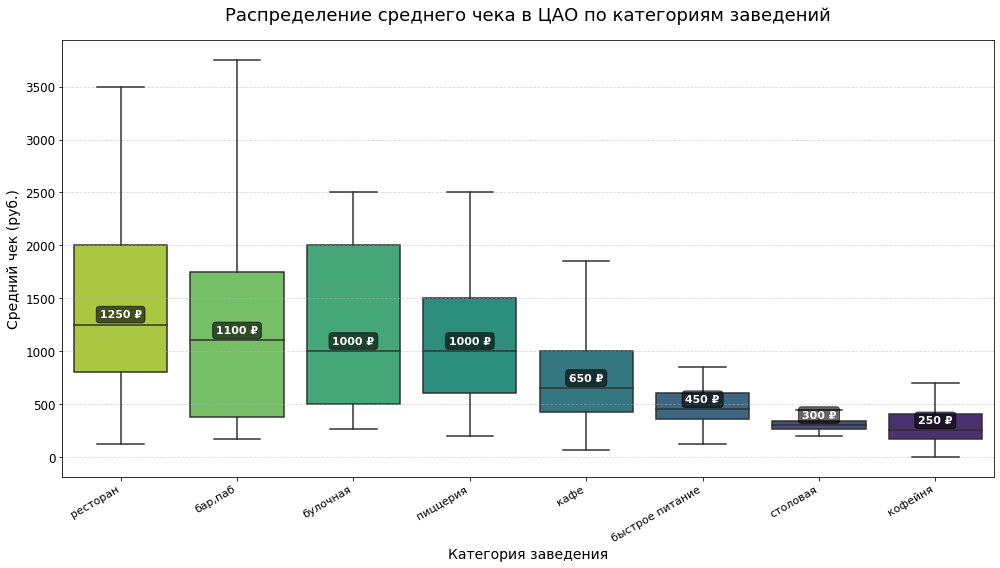

In [185]:
def plot_cao_bill_by_category(name='corrected_avg_bill'):
    plt.figure(figsize=(14, 8))
    
    caodf = rest_df[rest_df['distance'] == 0].copy()
    
    # считаем медианы и задаём порядок категорий
    medians = caodf.groupby('category')[name].median().sort_values(ascending=False)
    order = medians.index.tolist()
    
    ax = sns.boxplot(
        data=caodf,
        x='category',
        y=name,
        palette='viridis_r',
        showfliers=False,
        order=order
    )
    
    # наносим медианы в том же порядке
    for x, cat in enumerate(order):
        median = medians.loc[cat]
        ax.annotate(
            f'{median:.0f} ₽',
            xy=(x, median),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )

    plt.title('Распределение среднего чека в ЦАО по категориям заведений', fontsize=18, pad=20)
    plt.xlabel('Категория заведения', fontsize=14)
    plt.ylabel('Средний чек (руб.)', fontsize=14)
    plt.xticks(rotation=30, ha='right', fontsize=11)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    plt.tight_layout()
    plt.show()
    
plot_cao_bill_by_category('corrected_avg_bill')

👉 Видим, что для ресторана чек максимальный, 1250р, а в столовых и кофейнях минимальный: 250 - 300р. При этом, разброс у них минимален, а у булочной максимален.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

- Распределение заведений: кафе, кофейни и рестораны доминируют (68%), ЦАО лидирует по точкам (26%). в центре больше пабов (16%), меньше фастфуда и столовых.


- Сетевые заведения: Высокая доля сетей в кофейнях/пиццериях (51+%), низкая в пабах (22%) и столовых (27%).


- Рейтинг: коррелирует с ценой (phik +0.27), удаленностью от центра (phik -0.25) и категорией (+0.2 - +0.31). Пабы/рестораны лидируют (рейтинг 4.4), фастфуд отстает (рейтинг 4.05). Сети всреднем не дают преимущества, но в частности могут давать, например, Пицца Додо. Круглосуточность снижает оценку. Наилучшие рейтини у пабов (55/40% высокий/очень высокий) и пиццерий (72/23%).


- Чеки и посадочные места: Рестораны — 73 места, пиццерии/булочные — 44-50. Чеки падают к окраинам (1019₽ центр → 644₽ окраины), много выбросов. В ЦАО чеки выше в ресторанах (1250р) и ниже всего в столовых и кофейнях (300 - 250 р), но зато в последних двух низкий разброс чека.


- Топ-сети: Шоколадница (120 точек), Domino's/Dodo (~70), но рейтинг Шоколоадницы ниже (4.18 против 4.40 у редкой Булки).


- Данные требуют: фильтрацию выбросов по Q75, учет seats_type, corrected_avg_bill для надежности анализа.

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

Данные очищены, заполнены пропуски насколько возможно. Пропуски по ценам заполнены медианами на 100%, но только внутри второго датасета. На общее число пропусков ~50% это никак не повлияло. Введены новые категориальные переменные для анализа (**distance, is_24_7, rating_cat, seats_type, corrected_avg_bill**), чтобы увидеть нужные закономерности и ответить на вопросы зависимости rating от удалённости, вместимости, среднего чека, категории точки питания, членства в сети и тд.


### Задача 1. Категории заведений и их количество
- **Структура рынка:** В данных представлено **8 категорий** заведений общественного питания.
- **Доминирующие сегменты:** Основу рынка составляют три типа заведений: **Кафе, Кофейни и Рестораны** (суммарная доля — 68% от всех точек).
- **Нишевые категории:** Наименьшая доля принадлежит **Булочным** (всего 3%).
- **Баланс в быстром питании:** Доли **Пиццерий** и **Фастфуда** практически идентичны (по 7%).
- **Доля столовых:** Классические столовые занимают 4% рынка.

### Задача 2. Географическое распределение и специфика ЦАО
- **Лидер по концентрации:** **Центральный административный округ (ЦАО)** аккумулирует четверть (26%) всех заведений Москвы.
- **Аутсайдер:** Меньше всего точек общепита расположено в **Северо-Западном округе** (5%).
- **Равномерность остальных округов:** В остальных районах (кроме лидера и аутсайдера) концентрация заведений примерно одинакова — около **10%** на округ.
- **Специфика ЦАО (отличия от среднего по городу):**
    - **Рост доли Пабов:** В центре доля пабов вдвое выше средней по Москве (**16% против 9%**).
    - **Снижение доли Fast-casual:** Доля быстрого питания и столовых в ЦАО **в 2 раза ниже**.
    - **Стабильность Ресторанов:** Доля ресторанов в ЦАО сопоставима со среднемосковской и составляет **30%**.

### Задача 3. Сетевые и несетевые заведения
- **Общее соотношение:** В целом по Москве преобладают **несетевые** заведения. Доля сетевых точек составляет меньшинство — **38%**.
- **Лидеры по «сетевизации»:** Чаще всего сетевыми являются заведения категорий **Кофейни, Пиццерии и Булочные** (более **51%** точек в этих сегментах принадлежат сетям).
- **Аутсайдеры по «сетевизации»:** Реже всего сетевой формат встречается среди **Пабов** (всего **22%** сетевых) и **Столовых** (**27%**).

### Задача 4. Анализ посадочных мест (Seats)
- **Качество данных:** Данные по количеству посадочных мест **некачественные** и содержат значительное число выбросов справа (банкетные залы) из-за грубой категоризации (смешение ларьков и крупных ресторанов).
- **Типичные значения (средние с учетом очистки):**
    - **Максимум:** Рестораны — **73** места.
    - **Минимум:** Пиццерии и Булочные — **50** и **44** места соответственно.
    - **Средний сегмент:** Кофейни — **63** места.
- **Тренд:** Наблюдается почти линейное снижение среднего количества мест от ресторанов к булочным/пиццериям.

### Задача 5. Анализ рейтингов по категориям
- **Общий диапазон:** Распределение рейтингов смещено в высокую область **4.0 – 4.5** баллов.
- **Лидеры по качеству:** Наивысшие средние рейтинги и доли «отличников» характерны для **Баров, Пиццерий и Ресторанов**.
    - У Пабов и Ресторанов самая высокая доля заведений с высоким рейтингом (**40%** и **28%** соответственно).
- **Аутсайдеры:** Самые низкие рейтинги зафиксированы в категориях **Фастфуд** и **Кафе**.
    - Доля точек с «трешовым» (низким) рейтингом в этих сегментах достигает **5%**.

### Задача 6. Корреляция рейтинга с другими факторами
- **Ключевые драйверы рейтинга (ранжирование по силе связи):**
    1.  **Ценовая категория (Price):** Положительная корреляция (phik=0.27). Чем выше ценовой сегмент («Выше среднего»), тем выше и стабильнее рейтинг.
    2.  **Удаленность от центра (Distance):** Отрицательная корреляция (phik=-0.25). Лучшие рейтинги концентрируются в **Центре**; на окраинах (ЮЗ, ЮВ, СЗ, СВ) рейтинг снижается.
    3.  **Категория заведения (Category):** Существенное влияние (Пабы — высокий рейтинг, Фастфуд — низкий).
    4.  **Средний чек (middle_avg_bill):** Положительная связь (в дорогих точках рейтинг выше).
- **Слабые или отрицательные факторы:**
    - **Принадлежность к сети (Chain):** Корреляция с рейтингом практически **отсутствует**.
    - **Размер зала (Seats):** Влияния на рейтинг **не выявлено**.
    - **Круглосуточность (24/7):** Наличие этого признака **снижает** рейтинг заведения.

### Задача 7. Топ-15 популярных сетей Москвы
- **Лидер по количеству точек:** Сеть **«Шоколадница»** является абсолютным лидером по числу заведений (**120** точек), с большим отрывом опережая конкурентов.
- **Ближайшие конкуренты:** **«Доминос»** и **«Додо Пицца»** имеют примерно по **70** заведений.
- **Аутсайдер топа:** Сеть **«Му-Му»** имеет наименьшее количество точек среди топ-15 популярных сетей.
- **Расхождение количества и качества:** Лидер по числу точек («Шоколадница») демонстрирует отставание по среднему рейтингу (**4.18**) по сравнению с менее распространенными сетями (например, **«Буханка»** с рейтингом **4.40**).

### Задача 8. Вариация среднего чека по районам и удаленность от центра
- **Влияние центра:** Наблюдается прямая зависимость: с удалением от центра средний чек **падает примерно в 2 раза**.
- **Сравнение Центр vs Окраины (по медиане):**
    - **Центр:** 800 руб. (при среднем арифметическом 1019 руб. из-за выбросов дорогих ресторанов).
    - **Окраины (диагональ):** 450 руб.
- **Особенности данных:** Данные содержат сильные правые хвосты выбросов, поэтому для анализа цен корректнее использовать **медиану** или фильтрацию по 75-му перцентилю.
- **Разброс цен:** В **Центре** разброс среднего чека значительно **шире**, чем на окраинах.
- **Максимальный и минимальный чек по категориям:**
    - **Максимум:** **Рестораны** (≈ 1250 руб.).
    - **Минимум:** **Столовые и Кофейни** (250 – 300 руб.) с минимальным разбросом значений.


Всё это позволило ответить на главный вопрос цели анализа: "как открыть потенциально **более проходимую и прибыльную точку** общественного питания в Москве исходя из того, что чем выше рейтинг, тем больше проходимость". Рецепт таков:
- точку открывать в ЦАО;
- открывать паб, ресторан или пиццерию;
- средний чек нужно сделать "Выше среднего";
- режим работы обычный, некруглосуточный;
- можно подумать о франшизе Пиццы Додо, Хинкальной, Буханки, Лавки Караваевых: это способствует высокому рейтингу за счёт бренда и повышает проходимость.